# Clustering de Gliomas Mediante Perfiles de Metilación del ADN

**Autor:** solfloreslab
**Fecha:** 02/02/2026
**Dataset:** TCGA-LGG Methylation - LinkedOmics

## 0. Resumen Ejecutivo

En este trabajo se aplica aprendizaje no supervisado para identificar subgrupos latentes de gliomas de bajo grado (cohorte TCGA-LGG) a partir de perfiles de metilación del ADN (disponibles en LinkedOmics). El objetivo es evaluar si la señal epigenética permite descubrir agrupaciones con relevancia clínica, comparando después los clusters con variables clínicas (histología y supervivencia) únicamente como validación externa.

Pipeline: imputación (mediana) → filtrado por varianza → escalado (StandardScaler) → reducción de dimensionalidad (PCA: 94.85% de varianza explicada, ≈95%) → clustering (K-Means como modelo principal + GMM como alternativa) con evaluación interna (método del codo, silueta) y externa (Kaplan–Meier, log-rank).

Resultado principal: el modelo final seleccionado es K-Means con k=2 (silueta = 0.3144), que ofrece la mejor combinación de separación interna, parsimonia e interpretación clínica, y proporciona una estratificación pronóstica marcada (log-rank p = 8.65×10⁻²⁷), superior a la obtenida por la histología tradicional (p = 4.97×10⁻³). La estructura bipartita observada es compatible con la literatura sobre la biología molecular de gliomas basada en metilación; no obstante, esta interpretación se plantea como hipótesis y se desarrolla en la discusión.

Limitación clave: la ausencia de variables moleculares (IDH, 1p/19q, MGMT) impide mapear con certeza los clusters a subtipos OMS 2021; por tanto, la interpretación molecular se formula como hipótesis basada en literatura, no como diagnóstico confirmado.


## Índice

1. [Introducción y Contexto Clínico](#1-introducción-y-contexto-clínico)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Carga y Exploración de Datos](#3-carga-y-exploración-de-datos)
4. [Preprocesamiento y Reducción de Dimensionalidad](#4-preprocesamiento-y-reducción-de-dimensionalidad)
5. [Clustering](#5-clustering)
6. [Integración de Resultados y Validación Clínica](#6-integración-de-resultados-y-validación-clínica)
7. [Glosario](#7-glosario-términos-clave)
8. [Referencias Bibliográficas](#8-referencias-bibliográficas)

## 1. Introducción y Contexto Clínico

### 1.1 El Problema Clínico

Los gliomas difusos se encuentran entre los tumores primarios malignos del SNC más frecuentes en adultos [1]. La clasificación tradicional se basa en la apariencia histológica bajo el microscopio, dividiendo los tumores en grados II–III (gliomas de bajo grado o LGG) y grado IV (glioblastoma). Sin embargo, este enfoque tiene una limitación conocida: tumores histológicamente similares pueden presentar comportamientos biológicos y pronósticos muy diferentes.

Este problema ha sido descrito como la **"tiranía del microscopio"** [2]: la clasificación morfológica presenta variabilidad interobservador y no siempre captura la heterogeneidad biológica del tumor. Por ello, la integración de información molecular/epigenética (p. ej., perfiles de metilación) se ha vuelto clave para estratificar mejor a los pacientes. Estudios del consorcio TCGA demostraron que el análisis genómico integrativo identifica subgrupos moleculares más robustos y pronósticamente relevantes que la histología tradicional [3,4]. En consecuencia, la clasificación de la OMS de 2016 incorporó criterios moleculares, estableciendo que el estado de mutación de *IDH* y la codeleción 1p/19q forman parte de los criterios diagnósticos actuales [5]. Este enfoque ha sido validado clínicamente mediante herramientas como el clasificador de Heidelberg, que utiliza perfiles de metilación y algoritmos de machine learning para clasificar tumores del SNC con alta precisión [6].


### 1.2 Dataset y Perfiles de Metilación

Este proyecto utiliza datos de metilación del ADN del proyecto TCGA-LGG (The Cancer Genome Atlas - Low Grade Glioma), obtenidos del portal LinkedOmics [7]. El fichero de metilación incluye 516 pacientes con gliomas de bajo grado (grados II y III). Los datos clínicos están disponibles para 515 de estos pacientes, por lo que la validación clínica se realizará sobre esta submuestra común.

La metilación del ADN es particularmente informativa en gliomas porque las mutaciones en *IDH* inducen un fenotipo hipermetilador característico denominado G-CIMP (*Glioma CpG Island Methylator Phenotype*) [8,9]. Este patrón epigenético genera una señal dominante en los perfiles de metilación y suele emerger como el eje principal de variación en análisis exploratorios [4].

El dataset cumple los criterios del análisis: más de 500 muestras, alta dimensionalidad (miles de variables), variables numéricas continuas y necesidad de preprocesamiento (manejo de valores faltantes, filtrado de características y escalado) antes de aplicar clustering.

### 1.3 Formulación del Problema: Aprendizaje No Supervisado

A diferencia de un enfoque supervisado, este proyecto aborda un problema de **aprendizaje no supervisado**. No existen etiquetas que guíen el entrenamiento; el objetivo es que los algoritmos identifiquen **estructura intrínseca** en los perfiles de metilación.

Desde el punto de vista biológico y según la OMS (WHO CNS5, 2021), los **gliomas difusos de tipo adulto** se agrupan principalmente en **tres tipos** definidos por alteraciones moleculares [10]:

| Tipo OMS (nombre actual) | Estado IDH | 1p/19q | Grados CNS WHO posibles | Nota  |
|---|---|---|---:|---|
| **Astrocitoma, IDH-mutante** | Mutante | No codeleción | 2–4 | Pronóstico global intermedio (depende del grado y otras alteraciones). |
| **Oligodendroglioma, IDH-mutante y codeleción 1p/19q** | Mutante | Sí codeleción | 2–3 | En general, mejor pronóstico. |
| **Glioblastoma, IDH-wildtype** | Wildtype | No aplica | 4 | En general, peor pronóstico. |

#### Clusters de metilación en gliomas (TCGA)

Estudios del consorcio TCGA han identificado que los perfiles de metilación permiten clasificar gliomas en subgrupos moleculares con mejor capacidad pronóstica que la histología tradicional [4]. El hallazgo principal es una separación en dos grandes grupos según el estado de mutación del gen IDH:

- **IDH-mutante**: Tumores con hipermetilación global (fenotipo G-CIMP), asociados a mejor pronóstico.
- **IDH-wildtype**: Tumores sin esta mutación, con hipometilación y peor pronóstico.

Esta bipartición constituye el eje dominante de variación en los datos de metilación y es la señal principal que capturan los algoritmos de clustering no supervisado [4,8].

Sin embargo, en este trabajo **no se dispone de esas variables moleculares** en la tabla clínica, por lo que la correspondencia exacta entre *clusters* y subtipos OMS no puede confirmarse; se evaluará la relevancia clínica de los *clusters* mediante **validación externa** (histología y supervivencia).

Por tanto, se analizarán soluciones candidatas sugeridas por métricas internas (codo y silueta) y se seleccionará el modelo final combinando métricas internas con validación externa (histología y supervivencia), evitando inferencias no sustentadas por los datos.

### 1.4 Enfoque Metodológico

Dado que los perfiles de metilación presentan alta dimensionalidad, se aplicará un pipeline de preprocesamiento y reducción de dimensionalidad antes del clustering: imputación de valores faltantes, filtrado por varianza, escalado y reducción con PCA. PCA permite concentrar la variación principal en un número reducido de componentes y facilita el uso de algoritmos como K-Means. Como técnica complementaria, se utilizará t-SNE exclusivamente para **visualización** de la estructura en 2D.

Se implementará K-Means como algoritmo principal y se evaluará GMM como alternativa. El número de clusters se estimará con el método del codo e índice de silueta. Finalmente, aunque el entrenamiento es no supervisado, se utilizarán variables clínicas (tipo histológico y supervivencia) únicamente para **validación externa e interpretación**, evaluando si los clusters descubiertos muestran significado clínico real.

## 2. Configuración del Entorno

Antes de comenzar, importamos las librerías necesarias y configuramos el entorno de trabajo. Siguiendo las buenas prácticas metodológicas, establecemos una semilla para garantizar reproducibilidad de los resultados.

Las librerías se organizan por funcionalidad:
- **Manipulación de datos:** pandas y numpy para operaciones con matrices y dataframes.
- **Visualización:** matplotlib y seaborn para gráficos estadísticos, incluyendo proyecciones 3D.
- **Preprocesamiento:** SimpleImputer para imputación de valores faltantes y StandardScaler para normalización (obligatorio antes de clustering basado en distancias).
- **Reducción de dimensionalidad:** PCA para reducción lineal y t-SNE para visualización no lineal.
- **Clustering:** K-Means como algoritmo principal y GMM como alternativa probabilística.
- **Métricas:** coeficiente de silueta para evaluar la calidad del clustering.
- **Análisis de supervivencia:** lifelines para curvas Kaplan-Meier y test log-rank (validación clínica).

In [1]:
# ==============================================================================
# 2. IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ==============================================================================

# --- Instalación de dependencias adicionales ---
!pip install lifelines -q

# --- Manipulación de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# --- Preprocesamiento ---
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- Reducción de dimensionalidad ---
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Clustering ---
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# --- Métricas de clustering ---
from sklearn.metrics import silhouette_score, silhouette_samples

# --- Análisis estadístico ---
from scipy.stats import median_abs_deviation

# --- Análisis de supervivencia ---
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

# --- Utilidades ---
import warnings
warnings.filterwarnings('ignore')

# --- Configuración visual ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False

# --- Semilla para reproducibilidad ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente")
print(f"Semilla para reproducibilidad: {RANDOM_STATE}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.2 MB/s eta 0:00:00
Librerías cargadas correctamente
Semilla para reproducibilidad: 42


## 3. Carga y Exploración de Datos

El análisis exploratorio de datos (EDA) es especialmente crítico en aprendizaje no supervisado, donde no disponemos de una variable objetivo que guíe el análisis. El objetivo de esta sección es:

1. **Evaluar la estructura y calidad de los datos:** dimensiones, tipos, valores faltantes.
2. **Detectar posibles problemas:** outliers, características con poca varianza, escalas heterogéneas.
3. **Explorar patrones iniciales:** distribución de valores, variabilidad entre genes.
4. **Fundamentar las decisiones de preprocesamiento** que se tomarán en la siguiente sección.

### 3.1 Carga del Dataset de Metilación

Se cargan los datos de metilación del ADN del proyecto TCGA-LGG desde el portal LinkedOmics [7]. El dataset contiene perfiles de metilación.

In [2]:
# ==============================================================================
# 3.1 CARGA DEL DATASET DE METILACIÓN
# ==============================================================================

import os
import gzip
import shutil
import urllib.request
from pathlib import Path

# --- Detectar entorno (Colab vs local) y definir carpeta de trabajo ---
def in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

BASE_DIR = Path("/content") if in_colab() else Path.cwd()
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno: {'Colab' if in_colab() else 'Local'}")
print(f"Carpeta de datos: {DATA_DIR.resolve()}")

# --- URLs de LinkedOmics (TCGA-LGG) ---
URLS = {
    "methylation": "https://linkedomics.org/data_download/TCGA-LGG/Human__TCGA_LGG__JHU_USC__Methylation__Meth450__01_28_2016__BI__Gene__Firehose_Methylation_Prepocessor.cct.gz",
    "clinical": "https://linkedomics.org/data_download/TCGA-LGG/Human__TCGA_LGG__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi"
}

FILES = {
    "methylation": str(DATA_DIR / "methylation_LGG.cct"),
    "clinical": str(DATA_DIR / "clinical_LGG.tsi")
}

# --- Función para descargar y descomprimir ---
def download_file(url, output_path):
    """Descarga un archivo desde URL. Si es .gz, lo descomprime."""
    output_path = str(output_path)
    print(f"Descargando: {os.path.basename(output_path)}...")
    if url.endswith(".gz"):
        gz_path = output_path + ".gz"
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, "rb") as f_in:
            with open(output_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)
        os.remove(gz_path)
    else:
        urllib.request.urlretrieve(url, output_path)
    print(f"  -> Guardado: {output_path}")

# --- Descargar si no existen ---
for key in FILES:
    if not os.path.exists(FILES[key]):
        download_file(URLS[key], FILES[key])
    else:
        print(f"Ya existe: {os.path.basename(FILES[key])}")

# --- Cargar matriz de metilación ---
df_meth_raw = pd.read_csv(FILES["methylation"], sep="\t", index_col=0)

print(f"\nDimensiones originales (genes x pacientes): {df_meth_raw.shape}")
print(f"  - Genes (filas): {df_meth_raw.shape[0]:,}")
print(f"  - Pacientes (columnas): {df_meth_raw.shape[1]}")

# Transponer: convertir a formato estándar (pacientes x genes)
df_meth = df_meth_raw.T

print(f"\nDimensiones tras transponer (pacientes x genes): {df_meth.shape}")
print(f"  - Pacientes (filas): {df_meth.shape[0]}")
print(f"  - Genes (columnas): {df_meth.shape[1]:,}")

print(f"\nPrimeros 5 IDs de pacientes: {list(df_meth.index[:5])}")
print(f"Primeros 5 genes: {list(df_meth.columns[:5])}")


Entorno: Colab
Carpeta de datos: /content/data
Descargando: methylation_LGG.cct...
  -> Guardado: /content/data/methylation_LGG.cct
Descargando: clinical_LGG.tsi...
  -> Guardado: /content/data/clinical_LGG.tsi

Dimensiones originales (genes x pacientes): (20115, 516)
  - Genes (filas): 20,115
  - Pacientes (columnas): 516

Dimensiones tras transponer (pacientes x genes): (516, 20115)
  - Pacientes (filas): 516
  - Genes (columnas): 20,115

Primeros 5 IDs de pacientes: ['TCGA.CS.4938', 'TCGA.CS.4941', 'TCGA.CS.4942', 'TCGA.CS.4943', 'TCGA.CS.4944']
Primeros 5 genes: ['RBL2', 'VDAC3', 'ACTN1', 'ATP2A1', 'SFRP1']


La matriz original viene con genes en filas (20,115) y pacientes en columnas (516), por lo que se transpone para obtener el formato estándar de machine learning (muestras × características).

### 3.2 Carga de Datos Clínicos

Aunque el clustering se realizará exclusivamente sobre los datos de metilación (aprendizaje no supervisado), los datos clínicos serán fundamentales para validar e interpretar los clusters descubiertos.

Al igual que los datos de metilación, la matriz clínica viene con variables en filas y pacientes en columnas, por lo que también debe transponerse.

In [3]:
# ==============================================================================
# 3.2 CARGA DE DATOS CLÍNICOS
# ==============================================================================

# Cargar datos clínicos (variables en filas, pacientes en columnas)
df_clinical_raw = pd.read_csv(FILES["clinical"], sep='\t', index_col=0)

print(f"Dimensiones originales (variables x pacientes): {df_clinical_raw.shape}")

# Transponer: convertir a formato estándar (pacientes x variables)
df_clinical = df_clinical_raw.T

print(f"Dimensiones tras transponer (pacientes x variables): {df_clinical.shape}")
print(f"\nVariables clínicas disponibles:")
for i, col in enumerate(df_clinical.columns, 1):
    print(f"  {i}. {col}")

Dimensiones originales (variables x pacientes): (10, 515)
Dimensiones tras transponer (pacientes x variables): (515, 10)

Variables clínicas disponibles:
  1. years_to_birth
  2. Tumor_purity
  3. histological_type
  4. gender
  5. radiation_therapy
  6. race
  7. ethnicity
  8. overall_survival
  9. status
  10. overallsurvival


#### Verificación de correspondencia entre datasets

Antes de continuar, es esencial verificar que los pacientes en ambos datasets coincidan. Esta verificación evita errores en la validación posterior, donde necesitaremos asociar cada paciente con su cluster asignado y sus datos clínicos.

In [4]:
# ==============================================================================
# VERIFICACIÓN DE CORRESPONDENCIA ENTRE DATASETS
# ==============================================================================

pacientes_meth = set(df_meth.index)
pacientes_clinical = set(df_clinical.index)

# Pacientes en común
pacientes_comunes = pacientes_meth.intersection(pacientes_clinical)

# Pacientes solo en un dataset
solo_en_meth = pacientes_meth - pacientes_clinical
solo_en_clinical = pacientes_clinical - pacientes_meth

print("--- Verificación de IDs de pacientes ---")
print(f"Pacientes en metilación: {len(pacientes_meth)}")
print(f"Pacientes en datos clínicos: {len(pacientes_clinical)}")
print(f"Pacientes en común: {len(pacientes_comunes)} ({len(pacientes_comunes)/len(pacientes_meth)*100:.1f}%)")
print(f"Solo en metilación: {len(solo_en_meth)}")
print(f"Solo en clínico: {len(solo_en_clinical)}")

# Filtrar para mantener solo pacientes comunes
df_meth = df_meth.loc[list(pacientes_comunes)]
df_clinical = df_clinical.loc[list(pacientes_comunes)]

print(f"\nDataset filtrado: {df_meth.shape[0]} pacientes × {df_meth.shape[1]:,} genes")

--- Verificación de IDs de pacientes ---
Pacientes en metilación: 516
Pacientes en datos clínicos: 515
Pacientes en común: 515 (99.8%)
Solo en metilación: 1
Solo en clínico: 0

Dataset filtrado: 515 pacientes × 20,115 genes


La correspondencia entre datasets es excelente (99.8%). El único paciente sin datos clínicos será excluido para permitir la validación posterior de clusters con variables como el tipo histológico o la sobrevida.

### 3.3 Inspección Inicial del Dataset de Metilación

Examinamos la estructura básica de los datos: tipos de variables, presencia de valores faltantes, y rango de valores. Esta inspección es fundamental para identificar problemas que deban abordarse en el preprocesamiento.

In [5]:
# ==============================================================================
# 3.3 INSPECCIÓN INICIAL
# ==============================================================================

print("="*70)
print("INSPECCIÓN DEL DATASET DE METILACIÓN")
print("="*70)

print(f"\n--- Dimensiones ---")
print(f"Pacientes: {df_meth.shape[0]}")
print(f"Genes: {df_meth.shape[1]:,}")

print(f"\n--- Tipos de datos ---")
print(f"Todos los valores son numéricos (float64): {all(df_meth.dtypes == 'float64')}")

print(f"\n--- Valores faltantes ---")
total_nan = df_meth.isna().sum().sum()
total_valores = df_meth.shape[0] * df_meth.shape[1]
genes_con_nan = (df_meth.isna().sum() > 0).sum()
print(f"Total NaN: {total_nan:,} de {total_valores:,} ({total_nan/total_valores*100:.2f}%)")
print(f"Genes con al menos un NaN: {genes_con_nan:,} de {df_meth.shape[1]:,}")

print(f"\n--- Rango de valores ---")
print(f"Mínimo: {df_meth.min().min():.4f}")
print(f"Máximo: {df_meth.max().max():.4f}")
print(f"Media global: {df_meth.mean().mean():.4f}")

INSPECCIÓN DEL DATASET DE METILACIÓN

--- Dimensiones ---
Pacientes: 515
Genes: 20,115

--- Tipos de datos ---
Todos los valores son numéricos (float64): True

--- Valores faltantes ---
Total NaN: 6,073 de 10,359,225 (0.06%)
Genes con al menos un NaN: 2,038 de 20,115

--- Rango de valores ---
Mínimo: -0.4951
Máximo: 0.4948
Media global: -0.0180


**Observaciones de la inspección inicial:**

- **Dimensionalidad:** El dataset contiene 515 pacientes y 20,115 genes, lo que representa un problema de alta dimensionalidad típico de datos ómicos. Esta característica justifica la aplicación de técnicas de reducción de dimensionalidad antes del clustering.

- **Valores faltantes:** Se detectan 6,073 valores NaN (0.06% del total), distribuidos en 2,038 genes. Aunque el porcentaje es bajo, será necesario implementar una estrategia de imputación.

- **Rango de valores:** Los valores oscilan aproximadamente entre -0.5 y 0.5, con media cercana a 0. Según la documentación de LinkedOmics, los datos de metilación están expresados como "Beta Values (Val-0.5)", es decir, valores beta originales (rango 0-1) centrados restando 0.5 [7]. Esta transformación no afecta el análisis posterior. Sin embargo, dado que métodos como PCA y K-Means dependen de varianzas y distancias, será necesario estandarizar los datos para evitar que genes con mayor dispersión dominen el resultado.

### 3.4 Análisis Exploratorio

Antes de definir el pipeline de preprocesamiento, exploramos la distribución de los valores de metilación y la variabilidad entre genes. Este análisis permitirá identificar características del dataset que informen las decisiones posteriores.

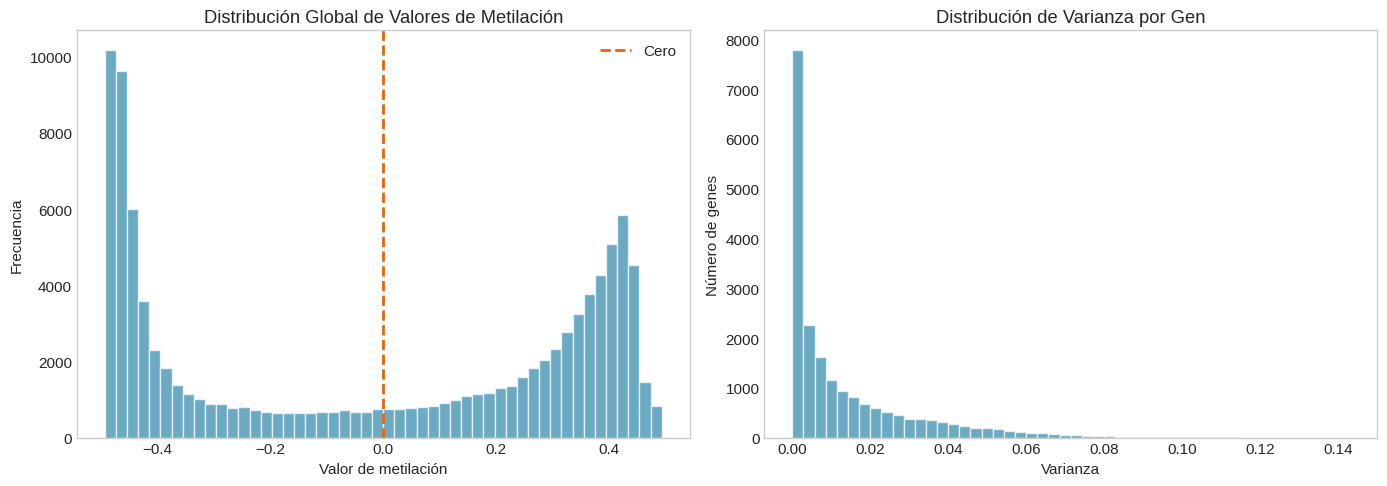

--- Estadísticas de varianza por gen ---
Varianza mínima: 0.000002
Varianza máxima: 0.142791
Varianza mediana: 0.005717
Genes con varianza > 0.01: 7,807
Genes con varianza > 0.005: 10,509


In [6]:
# ==============================================================================
# 3.4 ANÁLISIS EXPLORATORIO
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Distribución global de valores de metilación ---
# Tomar una muestra para el histograma (por eficiencia)
sample_values = df_meth.values.flatten()
sample_values = sample_values[~np.isnan(sample_values)]
sample_values = np.random.choice(sample_values, size=100000, replace=False)

axes[0].hist(sample_values, bins=50, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].axvline(x=0, color='#E8630A', linestyle='--', linewidth=2, label='Cero')
axes[0].set_xlabel('Valor de metilación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Global de Valores de Metilación')
axes[0].legend()

# --- Distribución de varianza por gen ---
gene_variance = df_meth.var(axis=0)

axes[1].hist(gene_variance, bins=50, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Varianza')
axes[1].set_ylabel('Número de genes')
axes[1].set_title('Distribución de Varianza por Gen')

plt.tight_layout()
plt.show()

# Estadísticas de varianza
print("--- Estadísticas de varianza por gen ---")
print(f"Varianza mínima: {gene_variance.min():.6f}")
print(f"Varianza máxima: {gene_variance.max():.6f}")
print(f"Varianza mediana: {gene_variance.median():.6f}")
print(f"Genes con varianza > 0.01: {(gene_variance > 0.01).sum():,}")
print(f"Genes con varianza > 0.005: {(gene_variance > 0.005).sum():,}")

**Observaciones del análisis exploratorio:**

El histograma de valores de metilación muestra una distribución bimodal con dos picos: uno en valores negativos (-0.4) y otro en valores positivos (+0.4). Esta distribución es característica de datos de metilación del ADN, donde los sitios CpG tienden a estar hipermetilados o hipometilados, siendo raros los estados intermedios.

El análisis de varianza revela que la mayoría de los genes presentan varianza muy baja, con una distribución fuertemente sesgada hacia valores cercanos a cero. La varianza mediana es 0.0057, mientras que solo 7,807 genes superan el umbral de 0.01 y 10,509 superan 0.005. Este patrón indica que una proporción considerable de genes no varía sustancialmente entre pacientes.

Estos hallazgos sugieren que un filtrado por dispersión podría reducir la dimensionalidad eliminando genes poco informativos. La selección del método de filtrado (varianza vs MAD, *Median Absolute Deviation*) y del umbral específico se abordarán más adelante.

### 3.5 Exploración de Datos Clínicos

Los datos clínicos no se utilizarán para el clustering (que se basa únicamente en metilación), pero permitirán validar e interpretar los resultados. Se exploran las variables disponibles y su distribución.

In [7]:
# ==============================================================================
# 3.5.1 EXPLORACIÓN DE DATOS CLÍNICOS
# ==============================================================================

print("="*70)
print("3.5 EXPLORACIÓN DE DATOS CLÍNICOS")
print("="*70)

print(f"\nDimensiones: {df_clinical.shape[0]} pacientes × {df_clinical.shape[1]} variables")

print("\n--- Variables disponibles ---")
for i, col in enumerate(df_clinical.columns, 1):
    print(f"  {i}. {col}")

print("\n--- Valores faltantes ---")
nulos = df_clinical.isna().sum()
nulos_con_faltantes = nulos[nulos > 0]
if len(nulos_con_faltantes) > 0:
    for var, n in nulos_con_faltantes.items():
        print(f"  {var}: {n} ({n/len(df_clinical)*100:.1f}%)")
else:
    print("  Sin valores faltantes")

print("\n--- Distribución: Tipo histológico ---")
hist_counts = df_clinical['histological_type'].value_counts()
for tipo, n in hist_counts.items():
    print(f"  {tipo}: {n} ({n/len(df_clinical)*100:.1f}%)")

print("\n--- Distribución: Género ---")
gender_counts = df_clinical['gender'].value_counts()
for genero, n in gender_counts.items():
    print(f"  {genero}: {n} ({n/len(df_clinical)*100:.1f}%)")

print("\n--- Distribución: Estado vital ---")
status_numeric = pd.to_numeric(df_clinical['status'], errors='coerce')
status_counts = status_numeric.value_counts(dropna=False).sort_index()
for estado, n in status_counts.items():
    if pd.isna(estado):
        label = "Faltante"
    elif estado == 1:
        label = "Fallecido"
    else:
        label = "Vivo/Censurado"
    print(f"  {label}: {n} ({n/len(df_clinical)*100:.1f}%)")

3.5 EXPLORACIÓN DE DATOS CLÍNICOS

Dimensiones: 515 pacientes × 10 variables

--- Variables disponibles ---
  1. years_to_birth
  2. Tumor_purity
  3. histological_type
  4. gender
  5. radiation_therapy
  6. race
  7. ethnicity
  8. overall_survival
  9. status
  10. overallsurvival

--- Valores faltantes ---
  years_to_birth: 1 (0.2%)
  radiation_therapy: 33 (6.4%)
  race: 10 (1.9%)
  ethnicity: 34 (6.6%)
  overall_survival: 34 (6.6%)
  status: 34 (6.6%)

--- Distribución: Tipo histológico ---
  astrocytoma: 194 (37.7%)
  oligodendroglioma: 191 (37.1%)
  oligoastrocytoma: 130 (25.2%)

--- Distribución: Género ---
  male: 285 (55.3%)
  female: 230 (44.7%)

--- Distribución: Estado vital ---
  Vivo/Censurado: 358 (69.5%)
  Fallecido: 123 (23.9%)
  Faltante: 34 (6.6%)


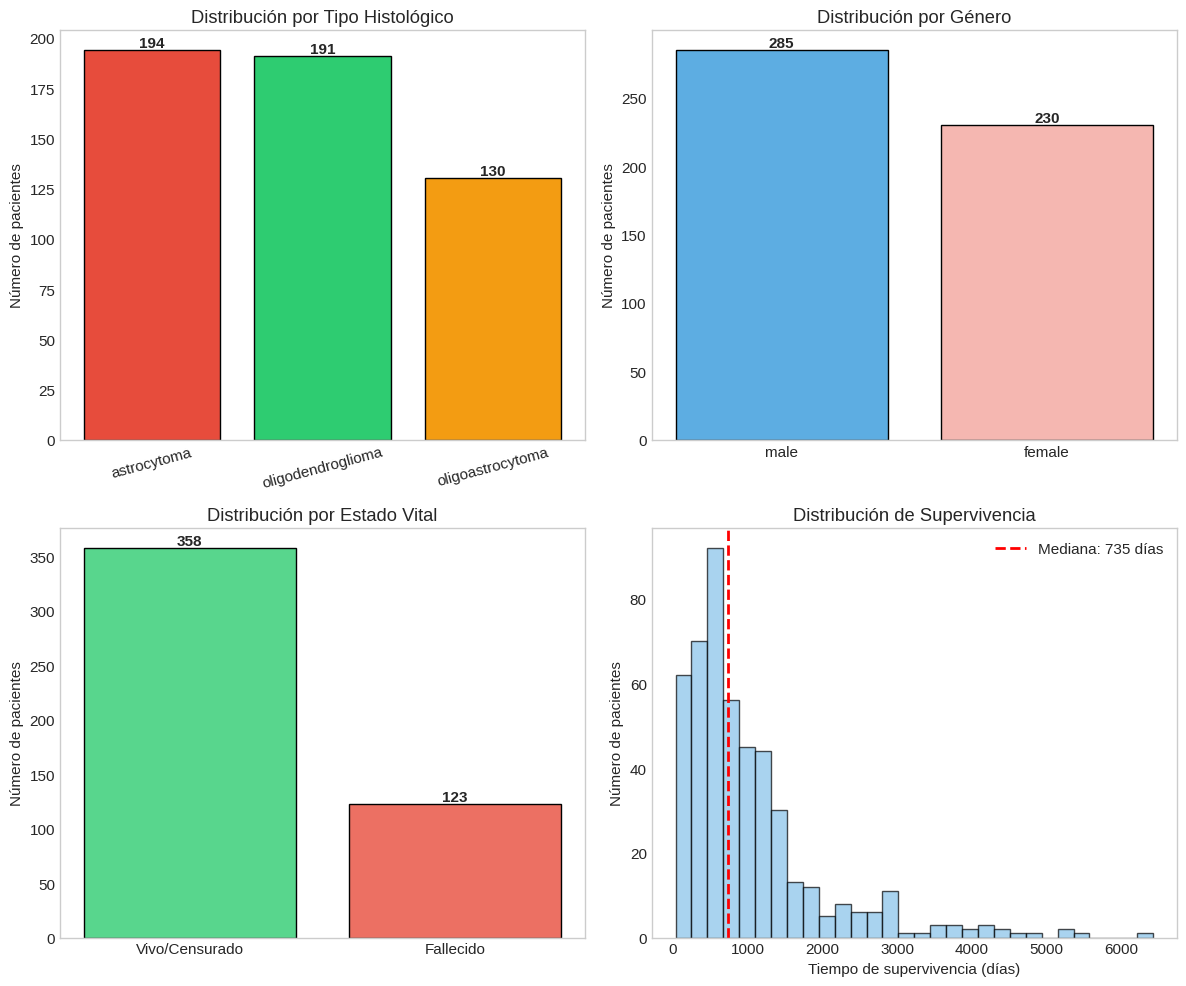

In [8]:
# ==============================================================================
# 3.5.2 VISUALIZACIÓN DE VARIABLES CLÍNICAS
# ==============================================================================

# Paleta de colores
COLOR_ASTRO = '#E74C3C'
COLOR_OLIGO = '#2ECC71'
COLOR_OLIGOASTRO = '#F39C12'
COLOR_MALE = '#5DADE2'
COLOR_FEMALE = '#F5B7B1'

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. Tipo histológico ---
hist_order = ['astrocytoma', 'oligodendroglioma', 'oligoastrocytoma']
hist_counts = df_clinical['histological_type'].value_counts()[hist_order]
colors_hist = [COLOR_ASTRO, COLOR_OLIGO, COLOR_OLIGOASTRO]

bars1 = axes[0, 0].bar(hist_counts.index, hist_counts.values, color=colors_hist, edgecolor='black')
axes[0, 0].set_ylabel('Número de pacientes')
axes[0, 0].set_title('Distribución por Tipo Histológico')
axes[0, 0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars1, hist_counts.values):
    axes[0, 0].annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# --- 2. Género ---
gender_counts = df_clinical['gender'].value_counts()
colors_gender = [COLOR_MALE, COLOR_FEMALE]

bars2 = axes[0, 1].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='black')
axes[0, 1].set_ylabel('Número de pacientes')
axes[0, 1].set_title('Distribución por Género')
for bar, count in zip(bars2, gender_counts.values):
    axes[0, 1].annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# --- 3. Estado vital ---
status_counts = df_clinical['status'].dropna().astype(int).value_counts().sort_index()
status_labels = ['Vivo/Censurado', 'Fallecido']
colors_status = ['#58D68D', '#EC7063']

bars3 = axes[1, 0].bar(status_labels, status_counts.values, color=colors_status, edgecolor='black')
axes[1, 0].set_ylabel('Número de pacientes')
axes[1, 0].set_title('Distribución por Estado Vital')
for bar, count in zip(bars3, status_counts.values):
    axes[1, 0].annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontweight='bold')

# --- 4. Distribución de supervivencia ---
survival_data = pd.to_numeric(df_clinical['overall_survival'], errors='coerce').dropna()
axes[1, 1].hist(survival_data, bins=30, color='#85C1E9', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(survival_data.median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {survival_data.median():.0f} días')
axes[1, 1].set_xlabel('Tiempo de supervivencia (días)')
axes[1, 1].set_ylabel('Número de pacientes')
axes[1, 1].set_title('Distribución de Supervivencia')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### Observaciones de la exploración clínica

**Variables disponibles:** 10 variables clínicas para 515 pacientes. Se observan valores faltantes en overall_survival y status (34 casos, 6.6%), radiation_therapy (33), ethnicity (34) y race (10).

**Tipo histológico:** distribución equilibrada entre astrocitoma (194, 37.7%), oligodendroglioma (191, 37.1%) y oligoastrocitoma (130, 25.2%). Esta clasificación tradicional servirá como referencia para evaluar los clusters.

**Género:** ligera predominancia masculina (285, 55.3%) frente a femenina (230, 44.7%), consistente con la epidemiología de gliomas.

**Estado vital:** 358 pacientes (74.4%) vivos o censurados al cierre del seguimiento, frente a 123 fallecidos (25.6%). La alta proporción de censura es habitual en estudios oncológicos.

**Supervivencia:** distribución asimétrica con cola derecha. La mediana es 735 días (aproximadamente 2 años), con algunos pacientes alcanzando seguimientos superiores a 5000 días (más de 13 años).

### 3.6 Visualización Exploratoria con PCA

Antes de definir las decisiones de preprocesamiento, aplicamos PCA como herramienta exploratoria para visualizar la estructura global de los datos. Según el la literatura de referencia, es parte fundamental del EDA en aprendizaje no supervisado.

Esta visualización preliminar nos permitirá:
- Evaluar si existe separación natural entre los pacientes.
- Informar las decisiones posteriores de preprocesamiento.

**Nota:** Para esta visualización exploratoria, aplicamos imputación y escalado de forma temporal solo para poder ejecutar PCA. Las decisiones formales de preprocesamiento se definirán en la siguiente sección.

3.6 PCA EXPLORATORIO

Varianza explicada por los primeros 10 componentes:
  PC1: 18.98% (acumulada: 18.98%)
  PC2: 6.62% (acumulada: 25.61%)
  PC3: 5.17% (acumulada: 30.77%)
  PC4: 3.37% (acumulada: 34.14%)
  PC5: 2.83% (acumulada: 36.97%)
  PC6: 2.52% (acumulada: 39.50%)
  PC7: 1.88% (acumulada: 41.38%)
  PC8: 1.70% (acumulada: 43.07%)
  PC9: 1.54% (acumulada: 44.62%)
  PC10: 1.42% (acumulada: 46.04%)


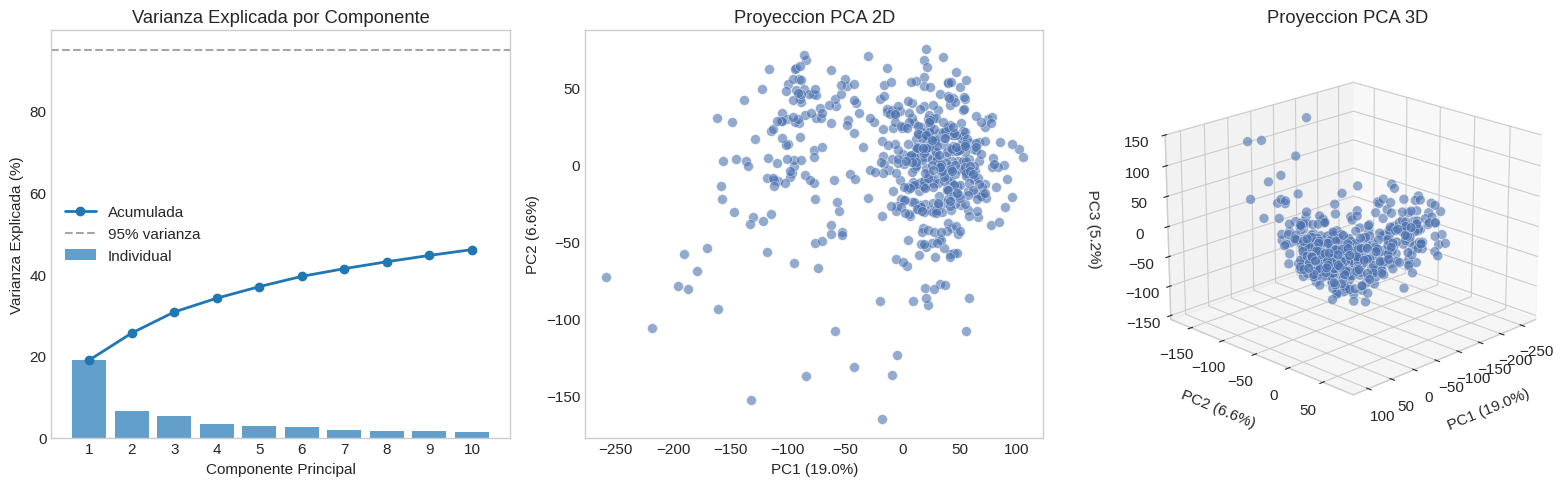


--- Resumen ---
Varianza explicada por PC1 + PC2: 25.61%
Varianza explicada por PC1 + PC2 + PC3: 30.77%
Componentes necesarios para 95% de varianza: no alcanzado con 10 componentes


In [9]:
# ==============================================================================
# 3.6 VISUALIZACION EXPLORATORIA CON PCA
# ==============================================================================

# --- Preparacion temporal de datos para visualizacion ---
imputer_temp = SimpleImputer(strategy='median')
df_meth_temp = pd.DataFrame(
    imputer_temp.fit_transform(df_meth),
    index=df_meth.index,
    columns=df_meth.columns
)

scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(df_meth_temp)

# --- PCA exploratorio ---
pca_explore = PCA(n_components=10, random_state=42)
X_pca_explore = pca_explore.fit_transform(X_scaled_temp)

var_explicada = pca_explore.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print("="*70)
print("3.6 PCA EXPLORATORIO")
print("="*70)
print("\nVarianza explicada por los primeros 10 componentes:")
for i in range(10):
    print(f"  PC{i+1}: {var_explicada[i]*100:.2f}% (acumulada: {var_acumulada[i]*100:.2f}%)")

# --- Visualizacion ---
fig = plt.figure(figsize=(16, 5))

# Grafico 1: Varianza explicada
ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(range(1, 11), var_explicada * 100, alpha=0.7, label='Individual')
ax1.plot(range(1, 11), var_acumulada * 100, 'o-', linewidth=2, label='Acumulada')
ax1.axhline(y=95, color='gray', linestyle='--', alpha=0.7, label='95% varianza')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Varianza Explicada por Componente')
ax1.legend()
ax1.set_xticks(range(1, 11))

# Grafico 2: Proyeccion PCA 2D
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_pca_explore[:, 0], X_pca_explore[:, 1],
            c='#4C72B0', alpha=0.6, edgecolors='white', linewidths=0.4, s=50)
ax2.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)')
ax2.set_title('Proyeccion PCA 2D')

# Grafico 3: Proyeccion PCA 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_pca_explore[:, 0], X_pca_explore[:, 1], X_pca_explore[:, 2],
            c='#4C72B0', alpha=0.6, edgecolors='white', linewidths=0.4, s=50)
ax3.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)', labelpad=10)
ax3.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)', labelpad=10)
ax3.set_zlabel(f'PC3 ({var_explicada[2]*100:.1f}%)', labelpad=10)
ax3.set_title('Proyeccion PCA 3D')
ax3.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# --- Resumen ---
print("\n--- Resumen ---")
print(f"Varianza explicada por PC1 + PC2: {(var_explicada[0] + var_explicada[1]) * 100:.2f}%")
print(f"Varianza explicada por PC1 + PC2 + PC3: {sum(var_explicada[:3]) * 100:.2f}%")

if var_acumulada[-1] >= 0.95:
    idx_95 = np.argmax(var_acumulada >= 0.95) + 1
    print(f"Componentes necesarios para 95% de varianza: {idx_95}")
else:
    print("Componentes necesarios para 95% de varianza: no alcanzado con 10 componentes")

**Observaciones de la visualización exploratoria:**

El análisis de varianza explicada muestra que los dos primeros componentes principales capturan el 25.61% de la varianza total (PC1: 19.0%, PC2: 6.6%). Al incorporar un tercer componente (PC3), la varianza acumulada asciende a 30.77%. Con 10 componentes se alcanza solo el 46.04%, lo que indica que la información relevante está distribuida en múltiples dimensiones, como es habitual en datos ómicos de alta dimensionalidad. Por lo tanto, tanto la proyección 2D como la 3D deben interpretarse como vistas parciales de la estructura global, sin asumir que reflejan toda la complejidad del espacio original.

La proyección PCA 2D sugiere estructura global en forma de regiones de mayor densidad, principalmente a lo largo de PC1, pero sin límites claros:

- Se observa una nube densa de puntos hacia valores positivos de PC1 (aprox. entre 0 y 80), con dispersión moderada en PC2.
- Aparece otra región de densidad hacia valores negativos de PC1 (aprox. entre -120 y -40), con mayor variabilidad vertical en PC2.
- Se identifican algunos puntos alejados del patrón principal (posibles outliers) en los extremos de PC1 y/o PC2, que conviene revisar antes de extraer conclusiones.

La proyección PCA 3D permite inspeccionar la posible contribución del tercer componente (PC3), que explica un 5.16% adicional de la varianza. Aunque añade cierta profundidad visual, los patrones observados se mantienen similares: una distribución continua sin fronteras nítidas. Esta vista complementaria sugiere que, si bien existen indicios de heterogeneidad, no hay una separación evidente entre grupos.

En conjunto, las proyecciones indican la presencia de estructura latente en los datos, pero no suficiente como para inferir agrupamientos definidos a simple vista. Esto justifica continuar con técnicas de reducción/selección de dimensionalidad más específicas y la aplicación de algoritmos de clustering no supervisado, validando después los resultados con variables clínicas disponibles (p. ej., supervivencia o histología), sin asumir una correspondencia directa a priori.


### 3.7 Limitaciones del Análisis Exploratorio

Con más de 20,000 variables (genes), ciertas técnicas habituales de EDA no son aplicables:

- **Pairplots y matrices de correlación:** Computacionalmente inviables y visualmente ininterpretables con esta dimensionalidad.
- **Boxplots individuales por variable:** No aportan información útil con miles de genes.
- **Detección de outliers variable por variable:** Impráctico con este número de características.

Por esta razón, el análisis exploratorio se ha centrado en la distribución global de valores, el análisis de varianza por gen (para informar el filtrado posterior), la exploración de las variables clínicas que servirán para validación, y una visualización preliminar mediante PCA. Esta última sugiere heterogeneidad en los datos y motiva la aplicación de técnicas de clustering, sin permitir conclusiones definitivas.

### 3.8 Resumen del EDA y Necesidades de Preprocesamiento

El análisis exploratorio ha identificado los siguientes hallazgos que requieren tratamiento antes del clustering:

| Aspecto | Hallazgo | Implicación |
|---------|----------|-------------|
| Valores faltantes | 0.06% NaN en 2,038 genes | Requiere imputación antes de aplicar PCA/clustering |
| Varianza por gen | Mayoría de genes con varianza muy baja | Requiere filtrado para retener genes informativos |
| Escala de valores | Varianzas heterogéneas entre genes | Requiere estandarización para evitar sesgos |
| Dimensionalidad | Varianza distribuida en muchos PCs | Requiere reducción dimensional antes del clustering |

La selección y justificación de cada técnica específica se desarrolla en la Sección siguiente.

## 4. Preprocesamiento y Reducción de Dimensionalidad

Este apartado implementa el pipeline de preprocesamiento: tratamiento de valores faltantes, filtrado por varianza, escalado y reducción de dimensionalidad con PCA. t-SNE se utiliza exclusivamente para visualización.

### 4.1 Tratamiento de Valores Faltantes

El EDA identificó 6,073 valores NaN (0.06% del total) distribuidos en 2,038 genes. Se aplica imputación con la **mediana por gen**, que es robusta a valores extremos y apropiada para la distribución bimodal característica de datos de metilación. El bajo porcentaje de valores faltantes minimiza el impacto de esta decisión en los resultados.

In [10]:
# ==============================================================================
# 4.1 TRATAMIENTO DE VALORES FALTANTES
# ==============================================================================

print("="*70)
print("4.1 TRATAMIENTO DE VALORES FALTANTES")
print("="*70)

# --- Estado antes de imputación ---
nan_antes = df_meth.isna().sum().sum()
genes_con_nan = (df_meth.isna().sum() > 0).sum()

print(f"\n--- Estado antes de imputación ---")
print(f"Total valores NaN: {nan_antes:,}")
print(f"Genes con al menos un NaN: {genes_con_nan:,} de {df_meth.shape[1]:,}")

# --- Imputación con mediana por gen ---
df_meth_imputed = df_meth.fillna(df_meth.median())

# --- Verificación post-imputación ---
nan_despues = df_meth_imputed.isna().sum().sum()

print(f"\n--- Verificación post-imputación ---")
print(f"Total valores NaN después: {nan_despues}")
print(f"Imputación completada: {'Sí' if nan_despues == 0 else 'No'}")

print(f"\n--- Dimensiones ---")
print(f"Antes:  {df_meth.shape[0]} pacientes × {df_meth.shape[1]:,} genes")
print(f"Después: {df_meth_imputed.shape[0]} pacientes × {df_meth_imputed.shape[1]:,} genes")

4.1 TRATAMIENTO DE VALORES FALTANTES

--- Estado antes de imputación ---
Total valores NaN: 6,073
Genes con al menos un NaN: 2,038 de 20,115

--- Verificación post-imputación ---
Total valores NaN después: 0
Imputación completada: Sí

--- Dimensiones ---
Antes:  515 pacientes × 20,115 genes
Después: 515 pacientes × 20,115 genes


### 4.2 Selección de Características por Dispersión

El EDA mostró que el 61% de los genes tienen varianza inferior a 0.01. Estos genes con valores casi constantes entre pacientes no aportan información discriminativa y retenerlos añade ruido sin beneficio.

**Comparación de métodos de filtrado**

Existen dos métricas habituales para selección por dispersión:

- **Varianza**: Sensible a valores extremos, pero estándar cuando los datos están bien normalizados.
- **MAD (Median Absolute Deviation)**: Más robusta a outliers, recomendada en literatura de metilación cuando hay valores atípicos [4].

Para evaluar si la elección afecta sustancialmente la selección, se comparan ambas métricas antes de tomar la decisión.

In [11]:
# ==============================================================================
# 4.2 SELECCIÓN DE CARACTERÍSTICAS - Comparación de métodos
# ==============================================================================

print("="*70)
print("4.2 SELECCIÓN DE CARACTERÍSTICAS POR DISPERSIÓN")
print("="*70)

# --- Calcular ambas métricas ---
gene_variance = df_meth_imputed.var(axis=0)
gene_mad = df_meth_imputed.apply(median_abs_deviation, axis=0)

print(f"\n--- Comparación de métricas ---")
print(f"{'Métrica':<12} {'Varianza':>12} {'MAD':>12}")
print("-"*38)
print(f"{'Mediana':<12} {gene_variance.median():>12.6f} {gene_mad.median():>12.6f}")
print(f"{'Media':<12} {gene_variance.mean():>12.6f} {gene_mad.mean():>12.6f}")

# --- Genes seleccionados por varianza ---
print(f"\n--- Filtrado por varianza ---")
for umbral in [0.005, 0.01, 0.02]:
    n_genes = (gene_variance > umbral).sum()
    pct = n_genes / len(gene_variance) * 100
    print(f"Varianza > {umbral}: {n_genes:,} genes ({pct:.1f}%)")

# --- Genes seleccionados por MAD (umbrales equivalentes) ---
print(f"\n--- Filtrado por MAD ---")
for umbral in [0.03, 0.05, 0.07]:
    n_genes = (gene_mad > umbral).sum()
    pct = n_genes / len(gene_mad) * 100
    print(f"MAD > {umbral}: {n_genes:,} genes ({pct:.1f}%)")

4.2 SELECCIÓN DE CARACTERÍSTICAS POR DISPERSIÓN

--- Comparación de métricas ---
Métrica          Varianza          MAD
--------------------------------------
Mediana          0.005716     0.024700
Media            0.013202     0.044261

--- Filtrado por varianza ---
Varianza > 0.005: 10,506 genes (52.2%)
Varianza > 0.01: 7,803 genes (38.8%)
Varianza > 0.02: 4,867 genes (24.2%)

--- Filtrado por MAD ---
MAD > 0.03: 9,032 genes (44.9%)
MAD > 0.05: 6,158 genes (30.6%)
MAD > 0.07: 4,323 genes (21.5%)


**Interpretación de la comparación**

El filtrado por varianza > 0.01 retiene 7,803 genes (~39%). Para obtener una cantidad similar con MAD se requeriría un umbral ~0.05 (6,158 genes). Dado que los datos de TCGA-LGG están preprocesados por LinkedOmics y no presentan valores atípicos extremos, ambos métodos producen selecciones comparables en este dataset.

**Decisión: filtrado por varianza > 0.01**

Se selecciona varianza por consistencia con la metodología de referencia. El umbral de 0.01 retiene 7,803 genes (38.8% del total), eliminando el 61.2% de genes con baja variabilidad que no aportan información discriminativa para el clustering.

In [12]:
# ==============================================================================
# 4.2 SELECCIÓN DE CARACTERÍSTICAS - Aplicación
# ==============================================================================

umbral_seleccionado = 0.01

genes_seleccionados = gene_variance[gene_variance > umbral_seleccionado].index
df_meth_filtered = df_meth_imputed[genes_seleccionados]

print(f"\n--- Filtrado aplicado ---")
print(f"Umbral de varianza: {umbral_seleccionado}")
print(f"Genes originales: {df_meth_imputed.shape[1]:,}")
print(f"Genes retenidos: {df_meth_filtered.shape[1]:,} ({df_meth_filtered.shape[1]/df_meth_imputed.shape[1]*100:.1f}%)")
print(f"Dimensiones resultantes: {df_meth_filtered.shape[0]} pacientes × {df_meth_filtered.shape[1]:,} genes")


--- Filtrado aplicado ---
Umbral de varianza: 0.01
Genes originales: 20,115
Genes retenidos: 7,803 (38.8%)
Dimensiones resultantes: 515 pacientes × 7,803 genes


### 4.3 Escalado de Datos

El escalado es obligatorio antes de PCA y algoritmos basados en distancias. Se aplica **StandardScaler** (estandarización a media 0 y varianza 1), siguiendo la "regla de oro" de la literatura de referencia. Sin escalado, los genes con mayor varianza dominarían los componentes principales.

In [13]:
# ==============================================================================
# 4.3 ESCALADO DE DATOS
# ==============================================================================

print("="*70)
print("4.3 ESCALADO DE DATOS")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_meth_filtered)

print(f"\n--- Verificación post-escalado ---")
print(f"Media global: {X_scaled.mean():.6f} (esperado: ~0)")
print(f"Desviación estándar global: {X_scaled.std():.6f} (esperado: ~1)")
print(f"\nDimensiones: {X_scaled.shape[0]} pacientes × {X_scaled.shape[1]:,} características")

4.3 ESCALADO DE DATOS

--- Verificación post-escalado ---
Media global: -0.000000 (esperado: ~0)
Desviación estándar global: 1.000000 (esperado: ~1)

Dimensiones: 515 pacientes × 7,803 características


### 4.4 Reducción de Dimensionalidad con PCA

PCA encuentra ejes ortogonales que maximizan la varianza de los datos proyectados. Es el paso previo estándar al clustering porque reduce dimensionalidad, elimina redundancia entre características correlacionadas y mitiga la maldición de la dimensionalidad que afecta a algoritmos basados en distancias como K-Means.

#### 4.4.1 Análisis de Varianza Explicada

El número de componentes a retener se determina mediante el criterio de varianza explicada acumulada.

In [14]:
# ==============================================================================
# 4.4.1 ANÁLISIS DE VARIANZA EXPLICADA
# ==============================================================================

print("="*70)
print("4.4.1 ANÁLISIS DE VARIANZA EXPLICADA")
print("="*70)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"\n--- Componentes necesarios por umbral de varianza ---")
print(f"80% de varianza: {n_80} componentes")
print(f"90% de varianza: {n_90} componentes")
print(f"95% de varianza: {n_95} componentes")

print(f"\n--- Varianza explicada (primeros 10 componentes) ---")
for i in range(10):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% (acumulada: {varianza_acumulada[i]*100:.2f}%)")

4.4.1 ANÁLISIS DE VARIANZA EXPLICADA

--- Componentes necesarios por umbral de varianza ---
80% de varianza: 160 componentes
90% de varianza: 283 componentes
95% de varianza: 370 componentes

--- Varianza explicada (primeros 10 componentes) ---
PC1: 31.19% (acumulada: 31.19%)
PC2: 7.46% (acumulada: 38.65%)
PC3: 4.19% (acumulada: 42.84%)
PC4: 3.52% (acumulada: 46.36%)
PC5: 2.50% (acumulada: 48.86%)
PC6: 1.44% (acumulada: 50.30%)
PC7: 1.14% (acumulada: 51.44%)
PC8: 0.93% (acumulada: 52.36%)
PC9: 0.92% (acumulada: 53.28%)
PC10: 0.73% (acumulada: 54.02%)


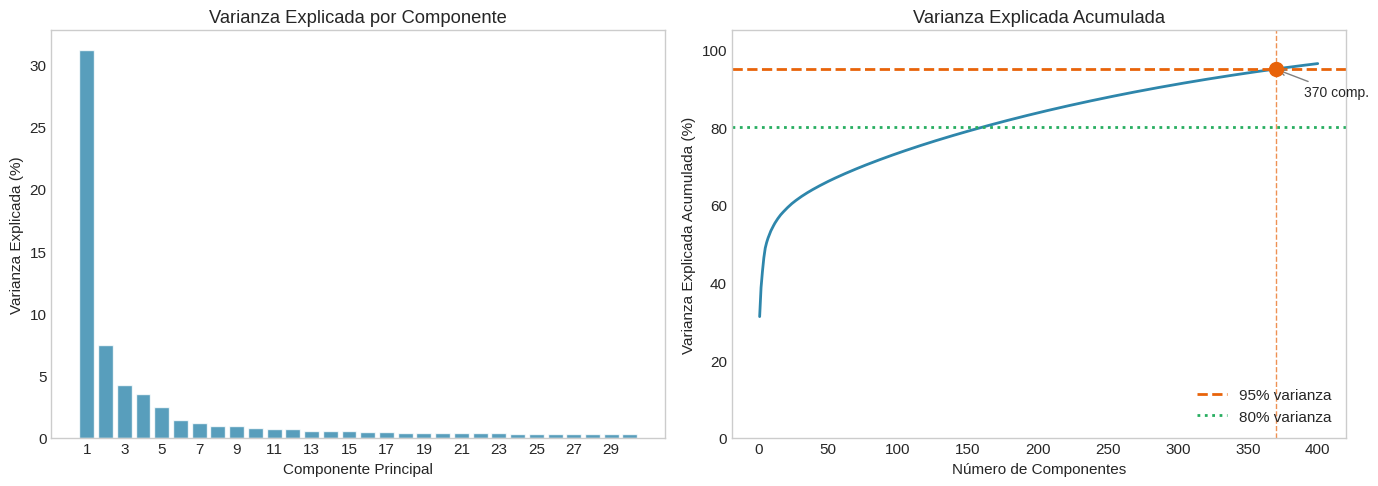

In [15]:
# --- Visualización de varianza explicada ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Varianza explicada por componente (primeros 30)
n_mostrar = 30
axes[0].bar(range(1, n_mostrar + 1),
            pca_full.explained_variance_ratio_[:n_mostrar] * 100,
            color='#2E86AB', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].set_xticks(range(1, n_mostrar + 1, 2))

# Gráfico 2: Varianza acumulada
n_plot = 400
axes[1].plot(range(1, n_plot + 1), varianza_acumulada[:n_plot] * 100,
             color='#2E86AB', linewidth=2)
axes[1].axhline(y=95, color='#E8630A', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axhline(y=80, color='#27AE60', linestyle=':', linewidth=2, label='80% varianza')
axes[1].axvline(x=n_95, color='#E8630A', linestyle='--', linewidth=1, alpha=0.7)
axes[1].scatter([n_95], [95], color='#E8630A', s=100, zorder=5)
axes[1].annotate(f'{n_95} comp.', xy=(n_95, 95), xytext=(n_95 + 20, 88),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada (%)')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend(loc='lower right')
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

#### Interpretación del análisis de varianza

El primer componente (PC1) captura el 31.2% de la varianza total, sugiriendo un eje principal de variación relacionado con el fenotipo G-CIMP. Los primeros 10 componentes acumulan solo el 54%, indicando que la información está distribuida en múltiples dimensiones.

**Selección del número de componentes**

| Umbral | Componentes | Observación |
|--------|-------------|-------------|
| 80% | ~180 | Reducción agresiva |
| 90% | 283 | Intermedio |
| 95% | 370 | Criterio conservador (estándar) |

**Decisión: retener 370 componentes (umbral 95% de varianza)**

Siguiendo el criterio establecido en el la literatura de referencia ("típicamente 95%"), se retienen 370 componentes. Esta decisión prioriza no perder información potencialmente relevante, dado que el objetivo es descubrir estructura latente mediante clustering. La reducción dimensional es sustancial: de 7,803 genes a 370 componentes.

#### 4.4.2 Aplicación de PCA

Siguiendo el criterio metodológico estándar, se retienen los componentes necesarios para explicar al menos el 95% de la varianza.

In [16]:
# ==============================================================================
# 4.4.2 APLICACION DE PCA (95% VARIANZA)
# ==============================================================================

print("="*70)
print("4.4.2 APLICACION DE PCA")
print("="*70)

# --- Aplicar PCA con componentes para 95% de varianza ---
pca = PCA(n_components=n_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n--- Resultado de la reduccion ---")
print(f"Dimensiones originales: {X_scaled.shape[1]:,} caracteristicas")
print(f"Dimensiones reducidas: {X_pca.shape[1]} componentes")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Reduccion de dimensionalidad: {(1 - X_pca.shape[1]/X_scaled.shape[1])*100:.1f}%")

4.4.2 APLICACION DE PCA

--- Resultado de la reduccion ---
Dimensiones originales: 7,803 caracteristicas
Dimensiones reducidas: 370 componentes
Varianza explicada: 94.85%
Reduccion de dimensionalidad: 95.3%


#### Decisión metodológica

Se retienen los componentes necesarios para explicar aproximadamente el 95% de la varianza total. Esta reducción de dimensionalidad facilita el clustering al eliminar ruido de alta frecuencia mientras preserva la estructura principal de los datos.

La matriz resultante X_pca será la entrada para los algoritmos de clustering K-Means y GMM.

### 4.5 Visualización Exploratoria Post-Preprocesamiento

Tras aplicar el pipeline de preprocesamiento, se visualizan los datos reducidos con PCA para evaluar la estructura resultante antes de aplicar clustering.

#### 4.5.1 Proyección PCA 2D y 3D

4.5.1 PROYECCION PCA 2D Y 3D


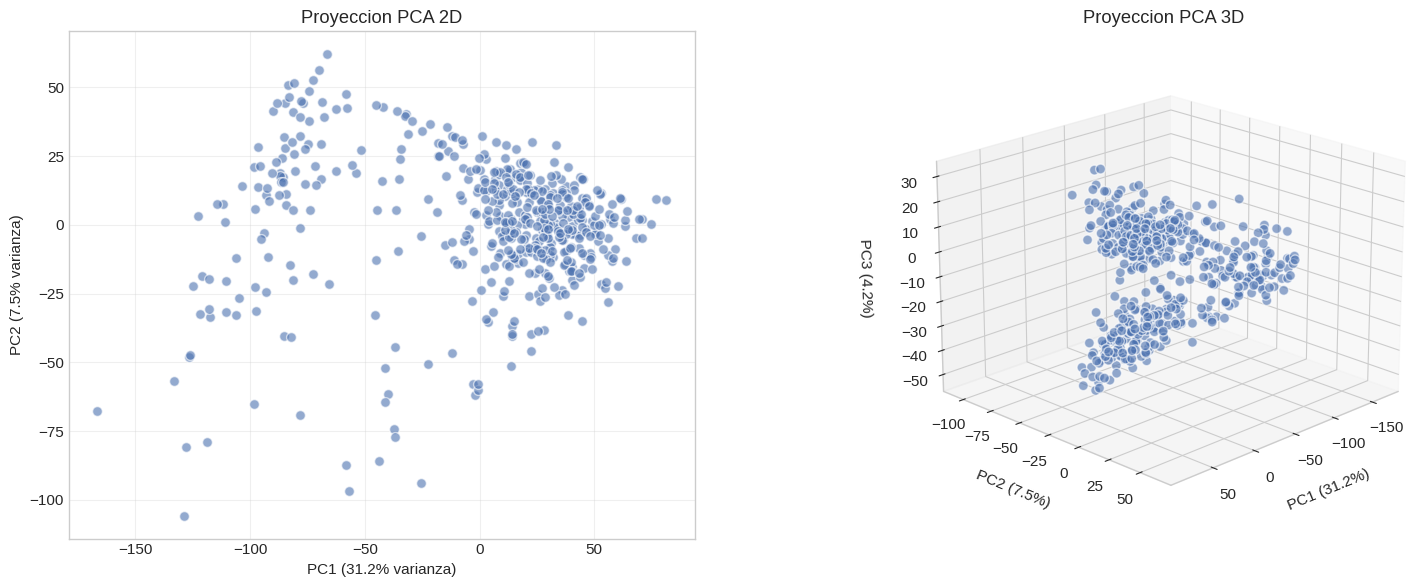

Varianza explicada: 2D = 38.7% | 3D = 42.8%


In [17]:
# ==============================================================================
# 4.5.1 PROYECCION PCA 2D Y 3D
# ==============================================================================

print("="*70)
print("4.5.1 PROYECCION PCA 2D Y 3D")
print("="*70)

df_pca_plot = pd.DataFrame(X_pca, index=df_meth_filtered.index)

fig = plt.figure(figsize=(15, 6))

# --- Grafico 2D ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(df_pca_plot[0], df_pca_plot[1],
            c='#4C72B0', alpha=0.6, edgecolors='white', s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax1.set_title('Proyeccion PCA 2D')
ax1.grid(True, alpha=0.3)

# --- Grafico 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(df_pca_plot[0], df_pca_plot[1], df_pca_plot[2],
            c='#4C72B0', alpha=0.6, edgecolors='white', s=50)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', labelpad=10)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', labelpad=10)
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', labelpad=10)
ax2.set_title('Proyeccion PCA 3D')
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

var_2d = (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]) * 100
var_3d = var_2d + pca.explained_variance_ratio_[2] * 100
print(f"Varianza explicada: 2D = {var_2d:.1f}% | 3D = {var_3d:.1f}%")


#### Interpretación

La proyección 2D muestra dos tendencias principales a lo largo de PC1:

- Una region densa hacia valores positivos de PC1 (aprox. entre -50 y +50), con dispersion moderada en PC2.
- Otra region más dispersa hacia valores negativos de PC1 (aprox. entre -150 y -50).

La proyección 3D confirma esta estructura bimodal con transición gradual entre ambos grupos.

Comparado con el PCA exploratorio del EDA (sobre 20,115 genes), la estructura se mantiene pero con mejor definicion: PC1 ahora explica el 31.2% de la varianza (vs 19.0% en EDA), indicando que el filtrado por varianza concentro la senal relevante eliminando genes poco informativos.

#### 4.5.2 Proyección t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica de reducción de dimensionalidad no lineal especializada en visualización. A diferencia de PCA, preserva las relaciones locales entre puntos cercanos, revelando estructuras que las proyecciones lineales podrian no capturar.

**Configuración de hiperparámetros (segun la literatura de referencia):**

**Pre-reducción con PCA:** Se aplica PCA a 50 componentes antes de t-SNE. Esto acelera el computo y reduce el ruido, siguiendo la recomendación de la literatura para datasets de alta dimensionalidad.

**Selección de perplexity:** El parámetro perplexity controla el balance entre preservar estructura local (valores bajos) vs global (valores altos). Segun el la literatura de referencia, la regla general es:

- perplexity aproximadamente n/4, con máximo de 50
- Para 515 pacientes: 515/4 = 128
- Aplicando el límite superior: **perplexity = 50**

**Nota metodológica:** Esta pre-reducción es independiente del PCA usado para clustering (370 componentes). t-SNE se usa exclusivamente para visualización; no debe usarse como entrada para clustering porque distorsiona las distancias globales.

4.5.2 PROYECCION t-SNE
Pre-reduccion: 7,803 -> 50 componentes
Varianza retenida: 66.0%

Aplicando t-SNE (perplexity=50)...
Completado: 515 pacientes x 2 dimensiones


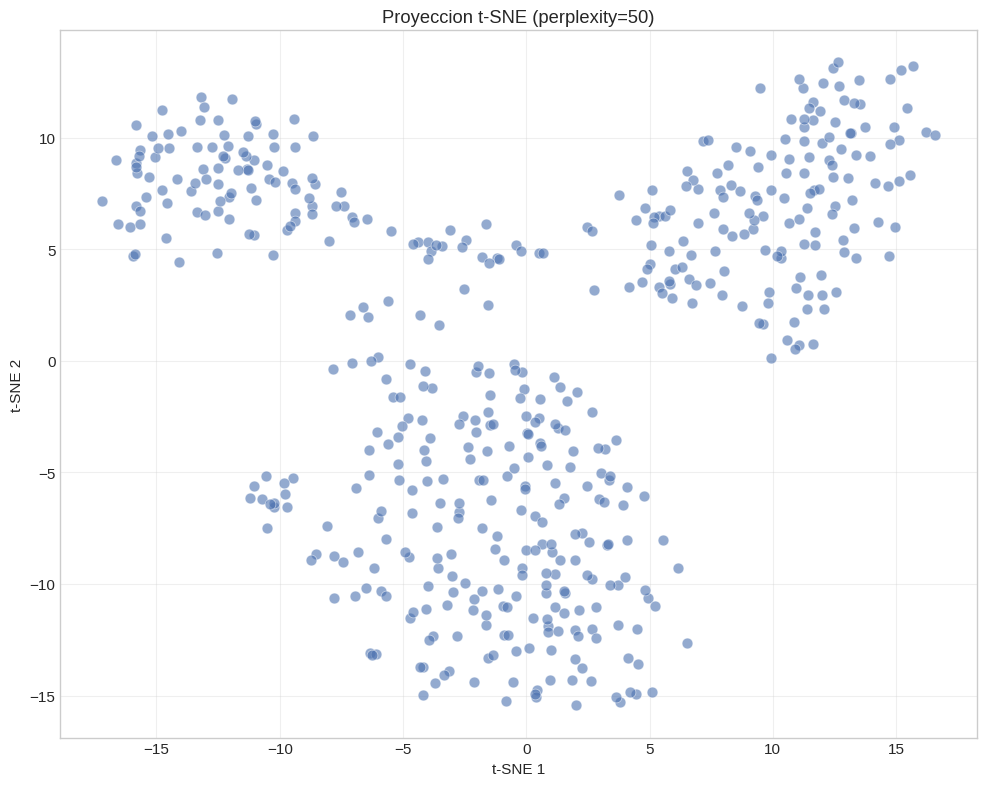

In [18]:
# ==============================================================================
# 4.5.2 PROYECCION t-SNE
# ==============================================================================

print("="*70)
print("4.5.2 PROYECCION t-SNE")
print("="*70)

# --- Pre-reduccion con PCA a 50 componentes ---
pca_pre_tsne = PCA(n_components=50, random_state=42)
X_pca_50 = pca_pre_tsne.fit_transform(X_scaled)

print(f"Pre-reduccion: {X_scaled.shape[1]:,} -> {X_pca_50.shape[1]} componentes")
print(f"Varianza retenida: {pca_pre_tsne.explained_variance_ratio_.sum()*100:.1f}%")

# --- Aplicar t-SNE ---
print("\nAplicando t-SNE (perplexity=50)...")

tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca_50)

print(f"Completado: {X_tsne.shape[0]} pacientes x {X_tsne.shape[1]} dimensiones")

# --- Visualizacion ---
df_tsne = pd.DataFrame(X_tsne, index=df_meth_filtered.index, columns=['t-SNE 1', 't-SNE 2'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df_tsne['t-SNE 1'], df_tsne['t-SNE 2'],
           c='#4C72B0', alpha=0.6, edgecolors='white', linewidths=0.5, s=60)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Proyeccion t-SNE (perplexity=50)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretación

t-SNE revela tres agrupaciones diferenciadas en la proyección 2D. Se observan dos grupos compactos en regiones opuestas del gráfico, junto con un tercer grupo más disperso en la zona central. Esta estructura sugiere la presencia de al menos tres subgrupos moleculares en los perfiles de metilación.

La separación es más definida que la observada en PCA 2D, donde solo se distinguían dos tendencias graduales a lo largo de PC1. Sin embargo, esta diferencia es esperable: t-SNE enfatiza la estructura local y puede exagerar la separación entre grupos.

El número óptimo de clusters se determinará formalmente mediante métricas internas (silueta, método del codo) sobre el espacio PCA, no sobre esta proyección.

#### 4.5.3 Comparación PCA vs t-SNE

Ambas técnicas de reducción de dimensionalidad tienen propósitos complementarios. La siguiente visualización permite comparar directamente sus proyecciones.

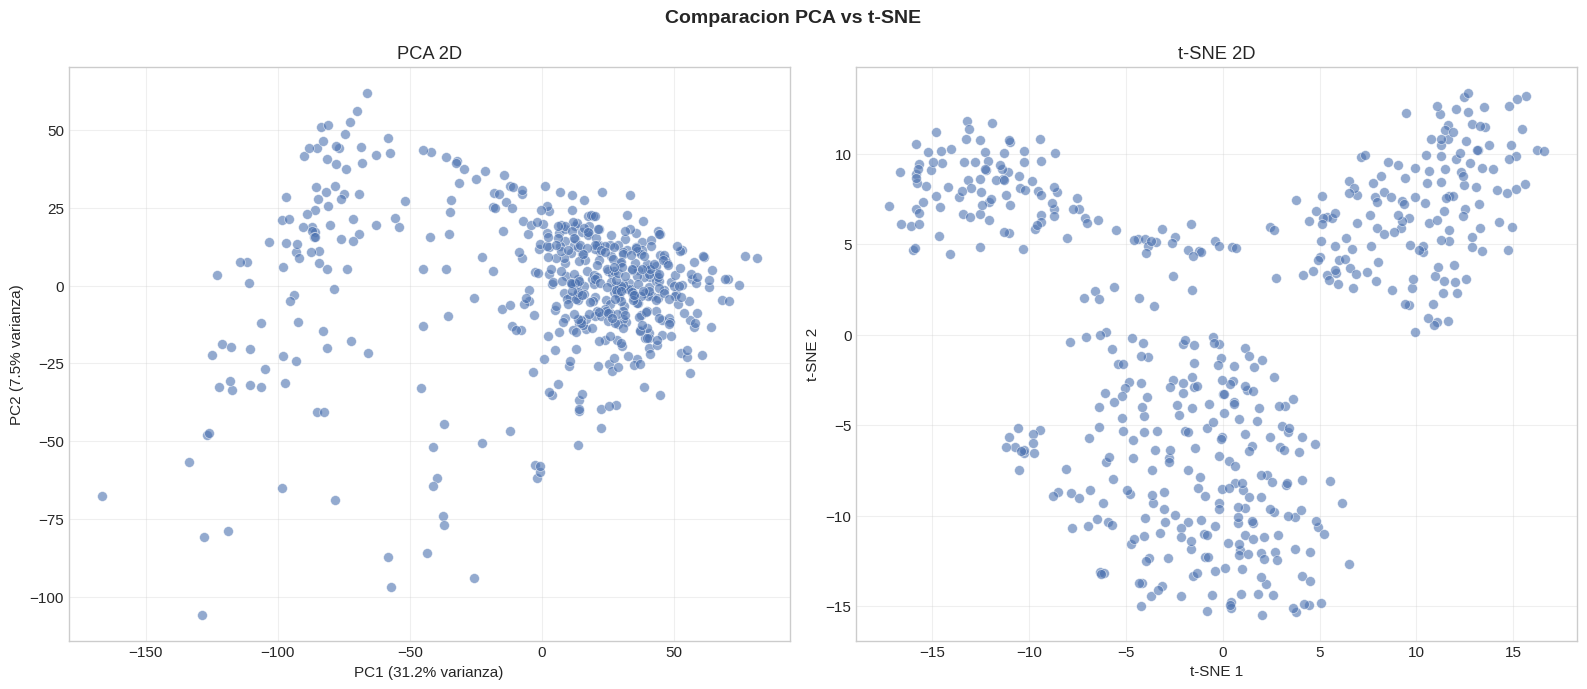

In [19]:
# ==============================================================================
# 4.5.3 COMPARACION PCA vs t-SNE
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(df_pca_plot[0], df_pca_plot[1],
                c='#4C72B0', alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[0].set_title('PCA 2D')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_tsne['t-SNE 1'], df_tsne['t-SNE 2'],
                c='#4C72B0', alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE 2D')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion PCA vs t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Conclusiones de la comparación

PCA muestra separación gradual a lo largo de PC1 preservando estructura global y distancias interpretables. t-SNE revela tres agrupaciones locales más definidas pero distorsiona distancias globales.

**Decisión metodológica:**

- Para clustering: 370 componentes de PCA (~95% varianza) como entrada para K-Means y GMM
- Para visualización de resultados: t-SNE

### 4.6 Resumen del Pipeline

El preprocesamiento se aplicó siguiendo la secuencia recomendada en la literatura. A continuación se resume cada transformación y se verifica el resultado final.

In [20]:
# ==============================================================================
# 4.6 RESUMEN DEL PIPELINE DE PREPROCESAMIENTO
# ==============================================================================

print("="*70)
print("4.6 RESUMEN DEL PIPELINE DE PREPROCESAMIENTO")
print("="*70)

print("\n--- Transformaciones aplicadas ---")
print(f"{'Paso':<35} {'Entrada':<20} {'Salida':<20}")
print("-"*75)
print(f"{'1. Datos originales':<35} {'-':<20} {'516 x 20,115':<20}")
print(f"{'2. Filtrado pacientes comunes':<35} {'516 x 20,115':<20} {'515 x 20,115':<20}")
print(f"{'3. Imputacion (mediana por gen)':<35} {'515 x 20,115':<20} {'515 x 20,115':<20}")
print(f"{'4. Filtrado (varianza > 0.01)':<35} {'515 x 20,115':<20} {f'515 x {X_scaled.shape[1]:,}':<20}")
print(f"{'5. Escalado (StandardScaler)':<35} {f'515 x {X_scaled.shape[1]:,}':<20} {f'515 x {X_scaled.shape[1]:,}':<20}")
print(f"{'6. PCA (~95% varianza)':<35} {f'515 x {X_scaled.shape[1]:,}':<20} {f'515 x {X_pca.shape[1]}':<20}")

print("\n--- Verificacion de calidad ---")
print(f"Valores NaN en matriz final: {np.isnan(X_pca).sum()}")
print(f"Varianza explicada retenida: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\n--- Datos listos para clustering ---")
print(f"Matriz para K-Means/GMM: X_pca con forma {X_pca.shape}")
print(f"Matriz para visualizacion: X_tsne con forma {X_tsne.shape}")

4.6 RESUMEN DEL PIPELINE DE PREPROCESAMIENTO

--- Transformaciones aplicadas ---
Paso                                Entrada              Salida              
---------------------------------------------------------------------------
1. Datos originales                 -                    516 x 20,115        
2. Filtrado pacientes comunes       516 x 20,115         515 x 20,115        
3. Imputacion (mediana por gen)     515 x 20,115         515 x 20,115        
4. Filtrado (varianza > 0.01)       515 x 20,115         515 x 7,803         
5. Escalado (StandardScaler)        515 x 7,803          515 x 7,803         
6. PCA (~95% varianza)              515 x 7,803          515 x 370           

--- Verificacion de calidad ---
Valores NaN en matriz final: 0
Varianza explicada retenida: 94.85%

--- Datos listos para clustering ---
Matriz para K-Means/GMM: X_pca con forma (515, 370)
Matriz para visualizacion: X_tsne con forma (515, 2)


## 5. Clustering

### 5.1 Selección de Algoritmos

La elección de algoritmos de clustering debe fundamentarse en las características del dataset y los objetivos del análisis. Según el la literatura de referencia, no existe un "mejor" algoritmo universal; la selección depende de la forma esperada de los clusters, la presencia de outliers y la dimensionalidad de los datos.

**Justificación de K-Means como algoritmo principal:**

K-Means es el punto de partida recomendado en la literatura por su simplicidad, eficiencia computacional e interpretabilidad. Para este dataset resulta apropiado porque:

1. Los datos ya están escalados (StandardScaler) y reducidos (PCA), cumpliendo los requisitos de K-Means.
2. La literatura sugiere que los subtipos moleculares de gliomas (IDH-mutante con/sin codeleción, IDH-wildtype) forman grupos relativamente compactos en el espacio de metilación, compatibles con clusters esféricos.
3. La visualización previa en PCA y t-SNE mostró agrupaciones diferenciadas que K-Means puede capturar.
4. La alta dimensionalidad (370 componentes de PCA) no es problema para K-Means, que escala bien con el número de características.

**Justificación de GMM como algoritmo alternativo:**

GMM (Gaussian Mixture Models) ofrece ventajas complementarias a K-Means:

1. Proporciona soft clustering (asignaciones probabilísticas), lo que permite identificar pacientes con alta incertidumbre, casos que podrían corresponder a fenotipos intermedios o tumores con características mixtas, una situación clínicamente relevante.
2. Puede modelar clusters elípticos, proporcionando mayor flexibilidad que los clusters esféricos de K-Means.
3. Los criterios AIC/BIC permiten una selección objetiva del número de componentes.
4. En contexto oncológico, conocer la probabilidad de pertenencia a cada subtipo puede informar decisiones clínicas más matizadas.

**Por qué no DBSCAN para este dataset:**

Aunque DBSCAN tiene ventajas (detección automática del número de clusters, identificación de outliers), presenta limitaciones importantes para datos de metilación de alta dimensionalidad:

1. DBSCAN es sensible a la "maldición de la dimensionalidad": en espacios de alta dimensionalidad (incluso tras PCA con 370 componentes), las distancias entre puntos tienden a homogeneizarse, dificultando la definición de vecindarios significativos.
2. La selección de los parámetros eps y min_samples resulta problemática cuando las densidades varían entre clusters, situación esperable en subtipos tumorales con prevalencias diferentes.
3. No esperamos que exista una población significativa de "ruido" o outliers verdaderos: los pacientes con glioma tienen un diagnóstico confirmado y deberían pertenecer a algún subtipo molecular.
4. La visualización previa en t-SNE no mostró clusters de formas arbitrarias que justifiquen DBSCAN sobre K-Means.

### 5.2 K-Means

#### 5.2.1 Determinación del Número Óptimo de Clusters

Para seleccionar el número óptimo de clusters se utilizan dos métodos complementarios según las indicaciones metodológicas: el método del codo (inercia vs k) y el coeficiente de silueta. En caso de conflicto, el criterio de interpretabilidad clínica será determinante.

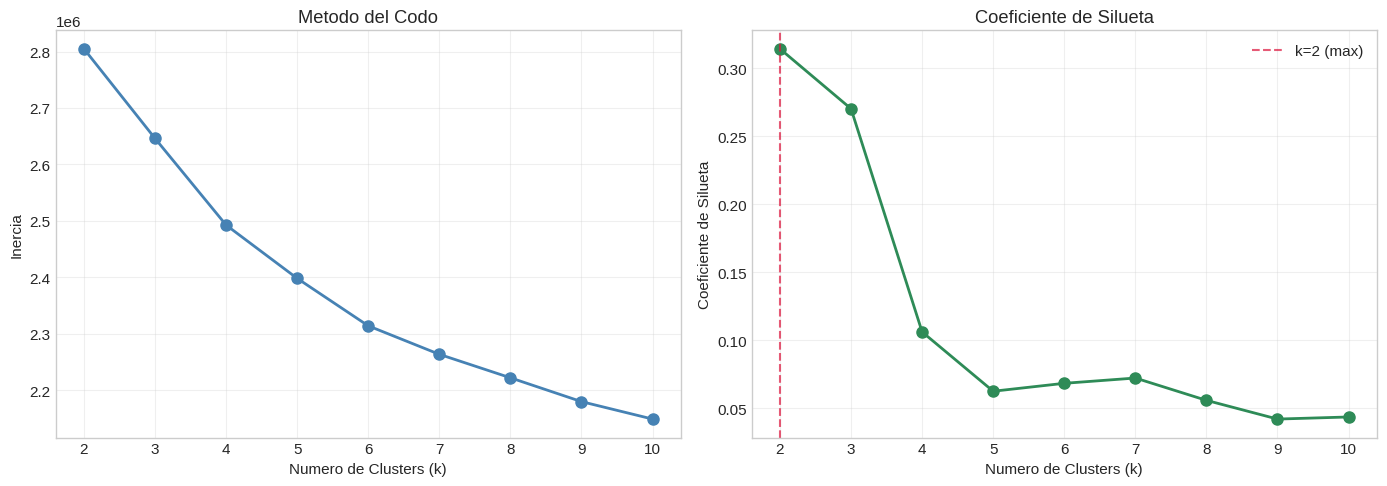

METRICAS POR NUMERO DE CLUSTERS
k     Inercia         Silueta     
--------------------------------
2     2804780.14      0.3144      
3     2645947.06      0.2704      
4     2492361.83      0.1062      
5     2397875.52      0.0626      
6     2313737.52      0.0685      
7     2263242.41      0.0723      
8     2221642.72      0.0559      
9     2179386.17      0.0422      
10    2148466.90      0.0437      


In [21]:
# ==============================================================================
# 5.2.1 DETERMINACION DEL NUMERO OPTIMO DE CLUSTERS
# ==============================================================================

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_pca)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels_temp))

# --- Visualizacion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metodo del Codo (sin linea - no hay codo claro)
axes[0].plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Metodo del Codo')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Coeficiente de Silueta (solo marcar k=2, el maximo)
axes[1].plot(k_range, silhouette_scores, 'o-', color='seagreen', linewidth=2, markersize=8)
axes[1].axvline(x=2, color='crimson', linestyle='--', linewidth=1.5, alpha=0.7, label='k=2 (max)')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Coeficiente de Silueta')
axes[1].set_xticks(list(k_range))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tabla de resultados ---
print("="*70)
print("METRICAS POR NUMERO DE CLUSTERS")
print("="*70)
print(f"{'k':<5} {'Inercia':<15} {'Silueta':<12}")
print("-"*32)
for k, iner, sil in zip(k_range, inertias, silhouette_scores):
    print(f"{k:<5} {iner:<15.2f} {sil:<12.4f}")

#### Interpretación de los resultados

**Método del Codo:** La curva de inercia decrece de forma gradual sin mostrar un punto de inflexión nítido. La mayor reducción relativa ocurre entre k=2 y k=3, pero no se observa un "codo" claro que sugiera un número óptimo de clusters de forma inequívoca.

**Coeficiente de Silueta:** El máximo se alcanza en k=2 (0.314), con un descenso moderado en k=3 (0.2704). A partir de k=4 la silueta cae drasticamente (0.1078), indicando que particiones con más clusters generan grupos poco cohesivos. La estructura dominante de los datos es bipartita.

**Resolucion del conflicto:** Ante la ausencia de un codo claro, el coeficiente de silueta se convierte en el criterio cuantitativo principal, favoreciendo k=2. No obstante, dado que k=3 presenta silueta positiva y t-SNE sugiere tres agrupaciones visuales, se analizaran ambas soluciones (k=2 y k=3) para evaluar su interpretabilidad clínica. La selección final se basara en métricas internas, estabilidad y validación externa.

#### 5.2.2 Aplicación de K-Means

Se entrenan dos modelos K-Means (k=2 y k=3) para comparar ambas soluciones candidatas. Se utiliza la inicialización K-Means++ con n_init=10 para asegurar estabilidad.

In [22]:
# ==============================================================================
# 5.2.2 APLICACIÓN DE K-MEANS (k=2 y k=3)
# ==============================================================================

# --- Entrenar ambos modelos ---
kmeans_k2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_k3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)

labels_k2 = kmeans_k2.fit_predict(X_pca)
labels_k3 = kmeans_k3.fit_predict(X_pca)

# --- Comparación inicial ---
print("="*70)
print("5.2.2 COMPARACIÓN K-MEANS: k=2 vs k=3")
print("="*70)

print(f"\n{'Métrica':<30} {'k=2':<15} {'k=3':<15}")
print("-"*60)
print(f"{'Inercia':<30} {kmeans_k2.inertia_:<15.2f} {kmeans_k3.inertia_:<15.2f}")
print(f"{'Silueta':<30} {silhouette_score(X_pca, labels_k2):<15.4f} {silhouette_score(X_pca, labels_k3):<15.4f}")
print(f"{'Iteraciones':<30} {kmeans_k2.n_iter_:<15} {kmeans_k3.n_iter_:<15}")

# --- Distribución de pacientes ---
print("\n--- Distribución de pacientes por cluster ---")
print("\nk=2:")
for cluster, count in zip(*np.unique(labels_k2, return_counts=True)):
    print(f"  Cluster {cluster}: {count} pacientes ({count/len(labels_k2)*100:.1f}%)")

print("\nk=3:")
for cluster, count in zip(*np.unique(labels_k3, return_counts=True)):
    print(f"  Cluster {cluster}: {count} pacientes ({count/len(labels_k3)*100:.1f}%)")

5.2.2 COMPARACIÓN K-MEANS: k=2 vs k=3

Métrica                        k=2             k=3            
------------------------------------------------------------
Inercia                        2804780.14      2645947.06     
Silueta                        0.3144          0.2704         
Iteraciones                    5               6              

--- Distribución de pacientes por cluster ---

k=2:
  Cluster 0: 394 pacientes (76.5%)
  Cluster 1: 121 pacientes (23.5%)

k=3:
  Cluster 0: 391 pacientes (75.9%)
  Cluster 1: 41 pacientes (8.0%)
  Cluster 2: 83 pacientes (16.1%)


**Resultados informativos:** El grupo mayoritario ubicado en valores positivos de PC1 (394 pacientes en k=2, 76.5%) se mantiene prácticamente intacto en k=3 (391 pacientes, 75.9%), lo que sugiere una identidad molecular distintiva y estable. El grupo minoritario en valores negativos de PC1 (121 pacientes en k=2, 23.5%) se subdivide en dos subgrupos más pequeños (41 y 83 pacientes, 8.0% y 16.1% respectivamente).

Nota: Los identificadores numéricos de cluster (0, 1, 2) son asignados arbitrariamente por el algoritmo y pueden variar entre ejecuciones; lo relevante es la estructura de los grupos, no sus etiquetas.

#### 5.2.3 Visualización de Resultados

Se proyectan las etiquetas de cluster en los espacios PCA 2D y t-SNE para comparar visualmente ambas soluciones. Estas proyecciones son solo para visualización; el clustering se realizó sobre los 370 componentes de PCA.

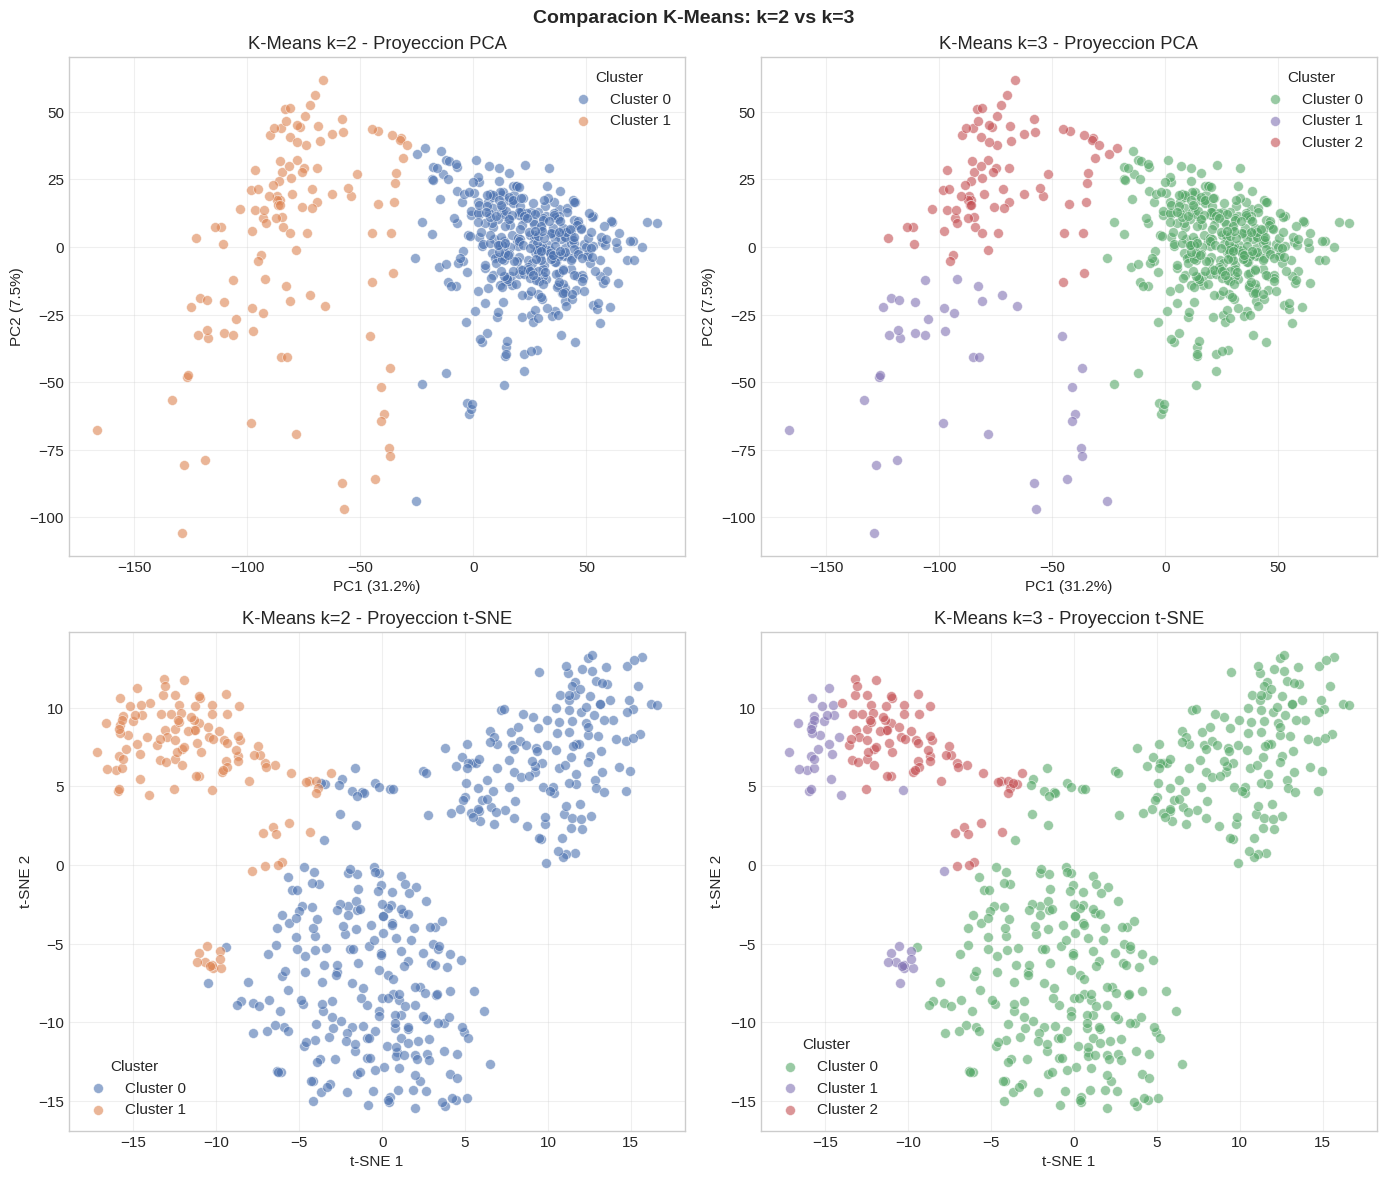

In [23]:
# ==============================================================================
# 5.2.3 VISUALIZACION DE RESULTADOS K-MEANS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Paletas DIFERENTES para evitar confusion
colores_k2 = {0: '#4C72B0', 1: '#DD8452'}  # Azul, Naranja
colores_k3 = {0: '#55A868', 1: '#8172B3', 2: '#C44E52'}  # Verde, Morado, Rojo

# --- PCA: k=2 ---
for cluster in [0, 1]:
    mask = (labels_k2 == cluster)
    axes[0, 0].scatter(df_pca_plot.loc[mask, 0], df_pca_plot.loc[mask, 1],
                       c=colores_k2[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 0].set_title('K-Means k=2 - Proyeccion PCA')
axes[0, 0].legend(title='Cluster')
axes[0, 0].grid(True, alpha=0.3)

# --- PCA: k=3 ---
for cluster in [0, 1, 2]:
    mask = (labels_k3 == cluster)
    axes[0, 1].scatter(df_pca_plot.loc[mask, 0], df_pca_plot.loc[mask, 1],
                       c=colores_k3[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 1].set_title('K-Means k=3 - Proyeccion PCA')
axes[0, 1].legend(title='Cluster')
axes[0, 1].grid(True, alpha=0.3)

# --- t-SNE: k=2 ---
for cluster in [0, 1]:
    mask = (labels_k2 == cluster)
    axes[1, 0].scatter(df_tsne.loc[mask, 't-SNE 1'], df_tsne.loc[mask, 't-SNE 2'],
                       c=colores_k2[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].set_title('K-Means k=2 - Proyeccion t-SNE')
axes[1, 0].legend(title='Cluster')
axes[1, 0].grid(True, alpha=0.3)

# --- t-SNE: k=3 ---
for cluster in [0, 1, 2]:
    mask = (labels_k3 == cluster)
    axes[1, 1].scatter(df_tsne.loc[mask, 't-SNE 1'], df_tsne.loc[mask, 't-SNE 2'],
                       c=colores_k3[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].set_title('K-Means k=3 - Proyeccion t-SNE')
axes[1, 1].legend(title='Cluster')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparacion K-Means: k=2 vs k=3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observaciones de la visualización

**Proyección PCA:**

- En k=2, la separación ocurre a lo largo de PC1: el grupo mayoritario (azul, ~76%) ocupa valores positivos, mientras que el grupo minoritario (naranja, ~24%) se ubica en valores negativos.
- En k=3, el grupo mayoritario (verde) permanece prácticamente intacto. El antiguo grupo minoritario se subdivide en dos clusters más pequeños (morado y rojo), ambos en la region de PC1 negativo.

**Proyección t-SNE:**

- En k=2, los clusters corresponden a las agrupaciones visuales esperadas: grupo disperso central-derecho (azul) y grupo compacto izquierdo (naranja).
- En k=3, la subdivision genera dos clusters (morado y rojo) que se solapan en el espacio t-SNE. Esto indica que la separación entre ellos ocurre en dimensiones que t-SNE no captura.

**Nota metodológica:** La subdivision en k=3 no produce separación clara en t-SNE, consistente con la silueta inferior de k=3 (0.2704) frente a k=2 (0.3145). Esto no invalida k=3, pero sugiere que k=2 captura la estructura dominante de los datos.

#### 5.2.4 Análisis de Clusters

Se calculan estadísticas descriptivas y se examina la composición por tipo histológico para ambas soluciones.

In [24]:
# ==============================================================================
# 5.2.4 ANALISIS DE CLUSTERS
# ==============================================================================

print("="*70)
print("5.2.4 ANALISIS DE CLUSTERS")
print("="*70)

# --- Tamano de clusters ---
print("\n--- Tamano de clusters ---")
print("\nk=2:")
for cluster, count in zip(*np.unique(labels_k2, return_counts=True)):
    print(f"  Cluster {cluster}: {count} pacientes ({count/len(labels_k2)*100:.1f}%)")

print("\nk=3:")
for cluster, count in zip(*np.unique(labels_k3, return_counts=True)):
    print(f"  Cluster {cluster}: {count} pacientes ({count/len(labels_k3)*100:.1f}%)")

# --- Media de componentes principales por cluster ---
print("\n--- Media de componentes principales por cluster ---")

df_pca_analysis = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'], index=df_meth_filtered.index)
df_pca_analysis['cluster_k2'] = labels_k2
df_pca_analysis['cluster_k3'] = labels_k3

print("\nk=2:")
print(df_pca_analysis.groupby('cluster_k2')[['PC1', 'PC2', 'PC3']].mean().round(2))

print("\nk=3:")
print(df_pca_analysis.groupby('cluster_k3')[['PC1', 'PC2', 'PC3']].mean().round(2))

5.2.4 ANALISIS DE CLUSTERS

--- Tamano de clusters ---

k=2:
  Cluster 0: 394 pacientes (76.5%)
  Cluster 1: 121 pacientes (23.5%)

k=3:
  Cluster 0: 391 pacientes (75.9%)
  Cluster 1: 41 pacientes (8.0%)
  Cluster 2: 83 pacientes (16.1%)

--- Media de componentes principales por cluster ---

k=2:
              PC1   PC2   PC3
cluster_k2                   
0           24.44 -0.50  0.85
1          -79.59  1.62 -2.77

k=3:
              PC1    PC2   PC3
cluster_k3                    
0           24.81  -0.44  0.87
1          -89.70 -46.74 -4.81
2          -72.59  25.18 -1.70


#### Interpretación del análisis de clusters

**Tamaño de clusters:**

- En k=2, la partición es asimétrica: un grupo mayoritario (76.5%) y uno minoritario (23.5%).
- En k=3, el grupo mayoritario se mantiene estable (75.9%), mientras que el grupo minoritario se subdivide en dos subgrupos más pequeños (8% y 16.1%).

**Separación en el espacio PCA:**

- La diferencia principal entre clusters ocurre en PC1: en k=2, un cluster presenta valores muy negativos (PC1 ~ -80), mientras que el otro presenta valores positivos (PC1 ~ +24). Esta separación refleja el eje dominante de variación en los datos de metilación.
- En k=3, el grupo con PC1 positivo permanece intacto. El grupo con PC1 negativo se subdivide en dos subgrupos que se diferencian principalmente en PC2 (valores opuestos en PC2), sugiriendo heterogeneidad adicional dentro de este grupo.

**Nota:** Los identificadores numéricos de cluster (0, 1, 2) son asignados arbitrariamente por K-Means y pueden variar entre ejecuciones. Lo relevante es la estructura de los grupos, no sus etiquetas.

### 5.3 Gaussian Mixture Models (GMM)

GMM ofrece un enfoque de soft clustering que asigna a cada paciente una probabilidad de pertenencia a cada cluster, en lugar de una asignación única (hard clustering). Esto permite identificar casos con alta incertidumbre, potencialmente relevantes en el contexto clínico de tumores con características moleculares intermedias.

#### 5.3.1 Selección del Número de Componentes

Para seleccionar el número de componentes se utilizan los criterios AIC (Akaike Information Criterion) y BIC (Bayesian Information Criterion), que penalizan la complejidad del modelo. Se busca el valor de k que minimice estos criterios.

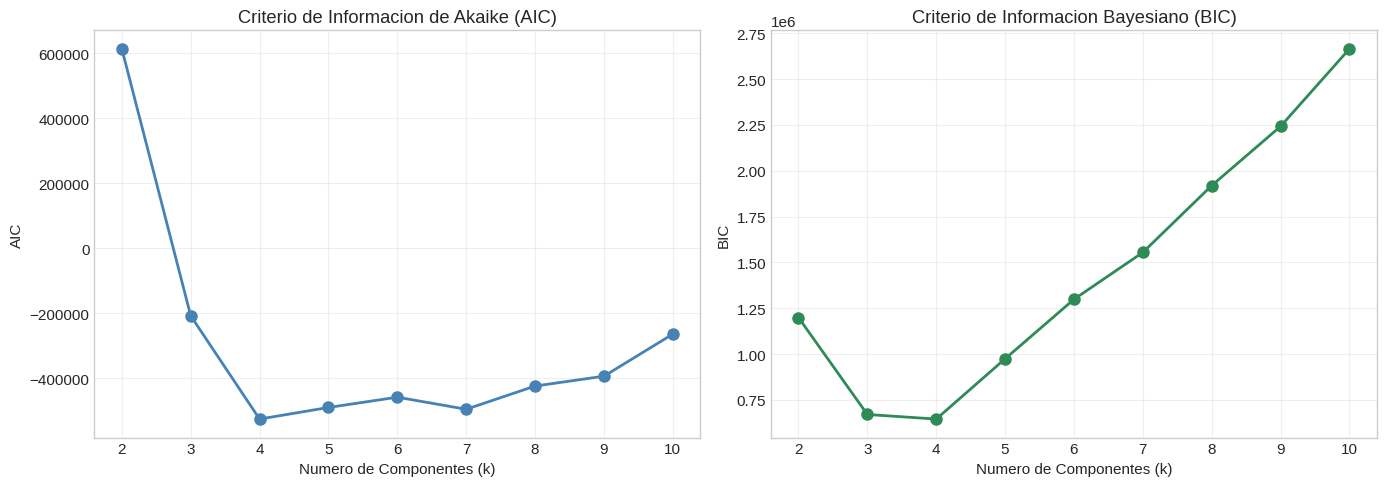

CRITERIOS AIC/BIC POR NUMERO DE COMPONENTES
k     AIC                  BIC                 
---------------------------------------------
2     613855.80            1199597.51          
3     -207858.74           670755.96           
4     -525762.06           645725.62           
5     -490084.97           974275.69           
6     -458371.27           1298862.38          
7     -495556.10           1554550.53          
8     -424094.61           1918884.99          
9     -393804.48           2242048.10          
10    -264112.94           2664612.63          

Minimo AIC: k=4 (-525762.06)
Minimo BIC: k=4 (645725.62)


In [25]:
# ==============================================================================
# 5.3.1 SELECCION DEL NUMERO DE COMPONENTES (GMM)
# ==============================================================================

from sklearn.mixture import GaussianMixture
from scipy.stats import entropy

k_range = range(2, 11)
aic_scores = []
bic_scores = []

for k in k_range:
    gmm_temp = GaussianMixture(n_components=k, covariance_type='full',
                                random_state=RANDOM_STATE, n_init=10)
    gmm_temp.fit(X_pca)
    aic_scores.append(gmm_temp.aic(X_pca))
    bic_scores.append(gmm_temp.bic(X_pca))

# --- Visualizacion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AIC
axes[0].plot(k_range, aic_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Componentes (k)')
axes[0].set_ylabel('AIC')
axes[0].set_title('Criterio de Informacion de Akaike (AIC)')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# BIC
axes[1].plot(k_range, bic_scores, 'o-', color='seagreen', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Componentes (k)')
axes[1].set_ylabel('BIC')
axes[1].set_title('Criterio de Informacion Bayesiano (BIC)')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tabla de resultados ---
print("="*70)
print("CRITERIOS AIC/BIC POR NUMERO DE COMPONENTES")
print("="*70)
print(f"{'k':<5} {'AIC':<20} {'BIC':<20}")
print("-"*45)
for k, aic, bic in zip(k_range, aic_scores, bic_scores):
    print(f"{k:<5} {aic:<20.2f} {bic:<20.2f}")

k_min_aic = list(k_range)[np.argmin(aic_scores)]
k_min_bic = list(k_range)[np.argmin(bic_scores)]
print(f"\nMinimo AIC: k={k_min_aic} ({min(aic_scores):.2f})")
print(f"Minimo BIC: k={k_min_bic} ({min(bic_scores):.2f})")

#### Interpretación AIC/BIC

Tanto AIC como BIC alcanzan su mínimo en k=4, coincidiendo en que GMM identifica cuatro componentes como solución óptima. Esto contrasta con K-Means, donde la silueta favorecía k=2.

Siguiendo el criterio de selección, se entrenará GMM con k=4. Adicionalmente, se evaluará GMM con k=2 para comparación directa con K-Means y determinar si el soft clustering aporta información adicional sobre la solución bipartita.



#### 5.3.2 Aplicación de GMM

Se entrena GMM con k=4 (según AIC/BIC) y k=2 (para comparar con K-Means), utilizando covarianza 'full' que permite modelar clusters de forma flexible.

In [26]:
# ==============================================================================
# 5.3.2 APLICACION DE GMM
# ==============================================================================

# --- GMM con k=4 (segun AIC/BIC) ---
gmm_k4 = GaussianMixture(n_components=4, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=10)
gmm_k4.fit(X_pca)
labels_gmm_k4 = gmm_k4.predict(X_pca)
probs_gmm_k4 = gmm_k4.predict_proba(X_pca)

# --- GMM con k=2 (para comparar con K-Means) ---
gmm_k2 = GaussianMixture(n_components=2, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=10)
gmm_k2.fit(X_pca)
labels_gmm_k2 = gmm_k2.predict(X_pca)
probs_gmm_k2 = gmm_k2.predict_proba(X_pca)

print("="*70)
print("5.3.2 APLICACION DE GMM")
print("="*70)

# --- Resultados k=4 ---
print("\n--- GMM k=4 (segun AIC/BIC) ---")
print(f"Convergencia: {gmm_k4.converged_}")
print(f"Silueta: {silhouette_score(X_pca, labels_gmm_k4):.4f}")
print("Distribucion por componente:")
for comp, count in zip(*np.unique(labels_gmm_k4, return_counts=True)):
    print(f"  Componente {comp}: {count} pacientes ({count/len(labels_gmm_k4)*100:.1f}%)")

# --- Resultados k=2 ---
print("\n--- GMM k=2 (comparacion con K-Means) ---")
print(f"Convergencia: {gmm_k2.converged_}")
print(f"Silueta: {silhouette_score(X_pca, labels_gmm_k2):.4f}")
print("Distribucion por componente:")
for comp, count in zip(*np.unique(labels_gmm_k2, return_counts=True)):
    print(f"  Componente {comp}: {count} pacientes ({count/len(labels_gmm_k2)*100:.1f}%)")

# --- Comparacion con K-Means ---
print("\n--- Comparacion de siluetas ---")
print(f"K-Means k=2: {silhouette_score(X_pca, labels_k2):.4f}")
print(f"GMM k=2:     {silhouette_score(X_pca, labels_gmm_k2):.4f}")
print(f"GMM k=4:     {silhouette_score(X_pca, labels_gmm_k4):.4f}")

5.3.2 APLICACION DE GMM

--- GMM k=4 (segun AIC/BIC) ---
Convergencia: True
Silueta: 0.0773
Distribucion por componente:
  Componente 0: 163 pacientes (31.7%)
  Componente 1: 100 pacientes (19.4%)
  Componente 2: 118 pacientes (22.9%)
  Componente 3: 134 pacientes (26.0%)

--- GMM k=2 (comparacion con K-Means) ---
Convergencia: True
Silueta: 0.3144
Distribucion por componente:
  Componente 0: 394 pacientes (76.5%)
  Componente 1: 121 pacientes (23.5%)

--- Comparacion de siluetas ---
K-Means k=2: 0.3144
GMM k=2:     0.3144
GMM k=4:     0.0773


#### Interpretación de resultados GMM

GMM k=4 (según AIC/BIC) produce una silueta muy baja (~ 0.080), indicando clusters poco cohesivos. Esto sugiere que la solución de 4 componentes, aunque optimiza el likelihood, no genera una partición geométricamente coherente.

GMM k=2 produce una silueta idéntica a K-Means (0.314) y la misma distribución de pacientes (394/121). Esto indica que ambos algoritmos identifican la misma estructura bipartita dominante.

#### 5.3.3 Análisis de Incertidumbre

La ventaja principal de GMM es proporcionar probabilidades de asignación (soft clustering), permitiendo identificar pacientes con alta incertidumbre que podrían corresponder a casos con características moleculares intermedias.

In [27]:
# ==============================================================================
# 5.3.3 ANALISIS DE INCERTIDUMBRE (GMM)
# ==============================================================================

print("="*70)
print("5.3.3 ANALISIS DE INCERTIDUMBRE")
print("="*70)

# --- Analisis para GMM k=2 ---
print("\n--- GMM k=2 ---")
max_probs_k2 = probs_gmm_k2.max(axis=1)
uncertainty_k2 = np.array([entropy(probs_gmm_k2[i]) for i in range(len(probs_gmm_k2))])

print(f"Probabilidad maxima - Media: {max_probs_k2.mean():.4f}")
print(f"Probabilidad maxima - Minimo: {max_probs_k2.min():.4f}")
print(f"Incertidumbre (entropia) - Media: {uncertainty_k2.mean():.4f}")
print(f"Incertidumbre (entropia) - Maxima: {uncertainty_k2.max():.4f}")
print(f"Pacientes con prob < 0.9: {(max_probs_k2 < 0.9).sum()}")
print(f"Pacientes con prob < 0.7: {(max_probs_k2 < 0.7).sum()}")

# --- Analisis para GMM k=4 ---
print("\n--- GMM k=4 ---")
max_probs_k4 = probs_gmm_k4.max(axis=1)
uncertainty_k4 = np.array([entropy(probs_gmm_k4[i]) for i in range(len(probs_gmm_k4))])

print(f"Probabilidad maxima - Media: {max_probs_k4.mean():.4f}")
print(f"Probabilidad maxima - Minimo: {max_probs_k4.min():.4f}")
print(f"Incertidumbre (entropia) - Media: {uncertainty_k4.mean():.4f}")
print(f"Incertidumbre (entropia) - Maxima: {uncertainty_k4.max():.4f}")
print(f"Pacientes con prob < 0.9: {(max_probs_k4 < 0.9).sum()}")
print(f"Pacientes con prob < 0.7: {(max_probs_k4 < 0.7).sum()}")

5.3.3 ANALISIS DE INCERTIDUMBRE

--- GMM k=2 ---
Probabilidad maxima - Media: 1.0000
Probabilidad maxima - Minimo: 1.0000
Incertidumbre (entropia) - Media: 0.0000
Incertidumbre (entropia) - Maxima: 0.0000
Pacientes con prob < 0.9: 0
Pacientes con prob < 0.7: 0

--- GMM k=4 ---
Probabilidad maxima - Media: 1.0000
Probabilidad maxima - Minimo: 1.0000
Incertidumbre (entropia) - Media: 0.0000
Incertidumbre (entropia) - Maxima: 0.0000
Pacientes con prob < 0.9: 0
Pacientes con prob < 0.7: 0


#### Interpretación del análisis de incertidumbre

Las probabilidades de asignación son exactamente 1.0 para todos los pacientes en ambas soluciones (k=2 y k=4). Es decir, GMM asigna cada paciente con certeza total a un único componente, sin casos ambiguos.

**Explicación técnica:** GMM con `covariance_type='full'` en un espacio de 370 dimensiones requiere estimar una matriz de covarianza completa para cada componente. Con 515 muestras, el modelo está severamente sobreparametrizado. Las gaussianas se ajustan de forma muy específica a cada cluster, produciendo probabilidades extremas.

**Consecuencia práctica:** La principal ventaja de GMM (soft clustering para identificar casos ambiguos) no se materializa en este dataset. Las asignaciones son efectivamente "hard", equivalentes a K-Means.

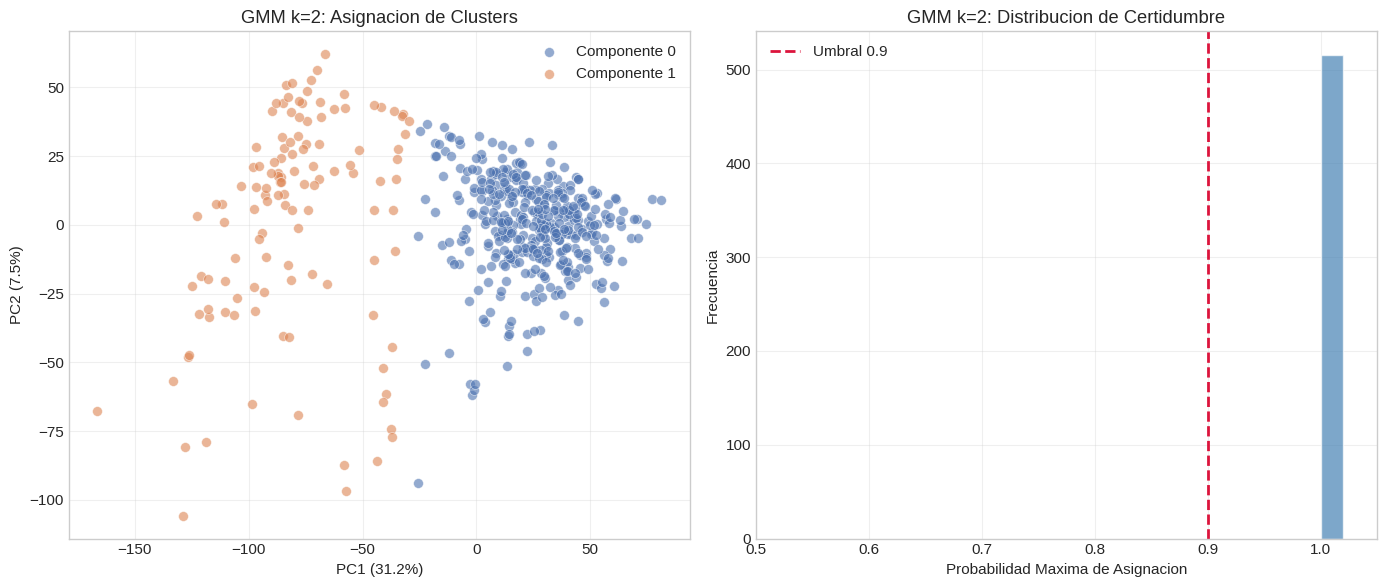


Nota: Todos los pacientes tienen probabilidad maxima = 1.0
El histograma muestra una unica barra en 1.0


In [28]:
# ==============================================================================
# 5.3.3 VISUALIZACION GMM
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Izquierda: Comparacion K-Means vs GMM k=2 ---
colors = {0: '#4C72B0', 1: '#DD8452'}

for cluster in [0, 1]:
    mask = (labels_gmm_k2 == cluster)
    axes[0].scatter(df_pca_plot.loc[mask, 0], df_pca_plot.loc[mask, 1],
                   c=colors[cluster], label=f'Componente {cluster}',
                   alpha=0.6, edgecolors='white', linewidths=0.5, s=50)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('GMM k=2: Asignacion de Clusters')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Derecha: Distribucion de probabilidad maxima ---
axes[1].hist(max_probs_k2, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0.9, color='crimson', linestyle='--', linewidth=2, label='Umbral 0.9')
axes[1].set_xlabel('Probabilidad Maxima de Asignacion')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('GMM k=2: Distribucion de Certidumbre')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0.5, 1.05)

plt.tight_layout()
plt.show()

print("\nNota: Todos los pacientes tienen probabilidad maxima = 1.0")
print("El histograma muestra una unica barra en 1.0")

#### Interpretación de la visualización GMM

El gráfico izquierdo muestra que GMM k=2 produce la misma separación espacial que K-Means, con clusters diferenciados principalmente por PC1. El gráfico derecho confirma que todos los pacientes tienen probabilidad máxima de 1.0 (barra única), indicando ausencia total de casos con incertidumbre en la asignación.

### 5.4 Comparación de Algoritmos

Se resumen los resultados de K-Means y GMM para seleccionar el algoritmo más apropiado.

#### 5.4.1 Resumen de Métricas Internas

| Algoritmo | Silueta | Distribución | Observación |
|-----------|---------|--------------|-------------|
| K-Means k=2 | ~0.31 | 394/121 | Mejor separación geométrica |
| K-Means k=3 | ~0.27 | 391/41/83 | Subdivide cluster minoritario |
| GMM k=2 | ~0.31 | 394/121 | Idéntico a K-Means |
| GMM k=4 (AIC/BIC) | ~0.08 | variable | Baja cohesión |

#### 5.4.2 Candidato Principal

Basándose únicamente en métricas internas, **K-Means k=2** emerge como el candidato principal:

1. **Mejor silueta (~0.31):** indica clusters bien separados y cohesivos.
2. **Parsimonia:** la estructura dominante es bipartita; k=3 no aporta separación adicional clara en el espacio PCA.
3. **GMM no aporta valor adicional:** las asignaciones probabilísticas son idénticas a K-Means (prob=1.0 para todos), por lo que el soft clustering no ofrece información sobre casos ambiguos.

**Nota:** La selección definitiva requiere validación externa. En la Sección 6 se evaluará si esta partición tiene relevancia clínica mediante análisis de supervivencia.

## 6. Integración de Resultados y Validación Clínica

### 6.1 Síntesis de Resultados No Supervisados

En la Sección 5 se evaluaron dos algoritmos de clustering (K-Means y GMM) sobre los 370 componentes principales que retienen el 94.85% de la varianza de los perfiles de metilación.

**Resumen de hallazgos técnicos:**

| Algoritmo | k | Silueta | Distribución | Observación |
|-----------|---|---------|--------------|-------------|
| K-Means | 2 | 0.314 | 394 / 121 | Mejor separación geométrica |
| K-Means | 3 | 0.270 | 391 / 41 / 83 | Subdivide el cluster minoritario |
| GMM | 2 | 0.314 | 394 / 121 | Asignación determinista (prob ≈ 1.0) |
| GMM | 4 (AIC/BIC) | 0.080 | Variable | Baja cohesión, clusters solapados |

**Observaciones clave:**

1. **Selección de k:** El método del codo no muestra un punto de inflexión nítido; el rango k=2–3 concentra la mayor ganancia marginal en inercia. La silueta sugiere que k=2 ofrece la separación geométrica global más clara (0.314 vs 0.270 para k=3).

2. **Comparación K-Means vs GMM:** Para k=2, GMM reproduce esencialmente la partición de K-Means, con asignaciones muy deterministas (probabilidad cercana a 1.0 en todos los pacientes). Para k=4 (sugerido por AIC/BIC), la silueta es muy baja (0.080), indicando clusters poco cohesionados o solapados. Por tanto, GMM no aporta valor adicional en este dataset y se selecciona K-Means como algoritmo final.

3. **Estructura de los datos:** La mayor parte de la variabilidad se organiza a lo largo de PC1, generando una separación en dos grupos principales (~76% y ~24% de pacientes).

**Nota metodológica:** Las variables clínicas (histología, supervivencia) se utilizan en esta sección únicamente para **validación externa**. El clustering se entrenó exclusivamente con datos de metilación.

### 6.2 Preparación de Datos para Validación Clínica

Se preparan los datos clínicos para el análisis de supervivencia, alineando las etiquetas de cluster con los pacientes que tienen información de seguimiento completa.

In [29]:
# ==============================================================================
# 6.2 PREPARACIÓN DE DATOS PARA ANÁLISIS DE SUPERVIVENCIA
# ==============================================================================

print("="*70)
print("6.2 PREPARACIÓN DE DATOS PARA ANÁLISIS DE SUPERVIVENCIA")
print("="*70)

# --- Crear Series con índice para los labels de cluster ---
labels_k2_series_full = pd.Series(labels_k2, index=df_meth_filtered.index)
labels_k3_series_full = pd.Series(labels_k3, index=df_meth_filtered.index)

# --- Preparar datos de supervivencia ---
df_survival = df_clinical.copy()
df_survival['overall_survival'] = pd.to_numeric(df_survival['overall_survival'], errors='coerce')
df_survival['status'] = pd.to_numeric(df_survival['status'], errors='coerce')
df_survival.dropna(subset=['overall_survival', 'status'], inplace=True)

print(f"\nPacientes con datos de supervivencia válidos: {len(df_survival)}")
print(f"Porcentaje de censura: {(df_survival['status'] == 0).sum() / len(df_survival) * 100:.1f}%")

# --- Extraer variables ---
survival_time_valid = df_survival['overall_survival']
survival_status_valid = df_survival['status']
histologia_valid = df_survival['histological_type']

# --- Alinear etiquetas ---
labels_k2_valid = labels_k2_series_full.loc[df_survival.index]
labels_k3_valid = labels_k3_series_full.loc[df_survival.index]

print(f"\nPacientes alineados: {len(labels_k2_valid)}")

6.2 PREPARACIÓN DE DATOS PARA ANÁLISIS DE SUPERVIVENCIA

Pacientes con datos de supervivencia válidos: 481
Porcentaje de censura: 74.4%

Pacientes alineados: 481


**Nota sobre tamaños de muestra:** El análisis de supervivencia se realiza sobre la subcohorte con datos válidos de seguimiento (n=481), por lo que los tamaños de cluster pueden diferir ligeramente del conjunto completo (n=515). Esta diferencia se debe a 34 pacientes (6.6%) sin información de supervivencia registrada.

### 6.3 Relación entre Clusters de Metilación y Clasificación Histológica

Antes de evaluar la supervivencia, se examina cómo se relacionan los clusters de metilación con la clasificación histológica tradicional. Esta comparación permite entender si la metilación captura información diferente a la morfología.

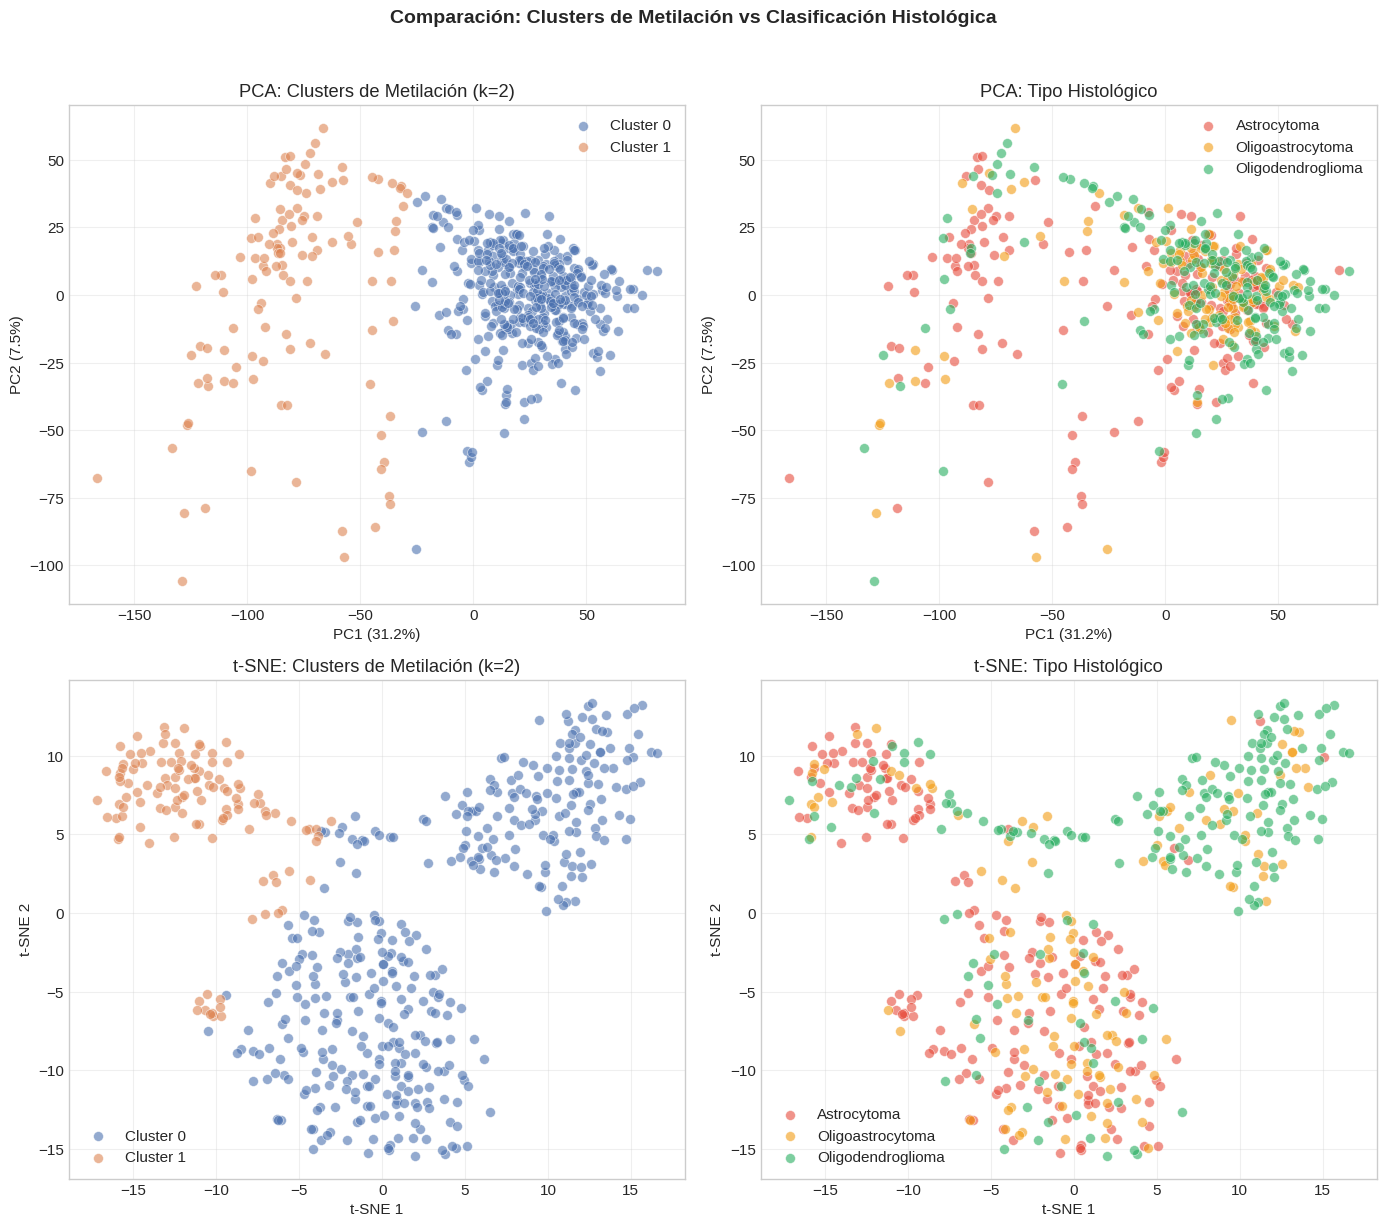

In [30]:
# ==============================================================================
# 6.3 COMPARACIÓN ESPACIAL: CLUSTERS vs HISTOLOGÍA
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Colores
colores_cluster = {0: '#4C72B0', 1: '#DD8452'}
colores_hist = {'astrocytoma': '#E74C3C', 'oligoastrocytoma': '#F39C12', 'oligodendroglioma': '#27AE60'}

# Obtener histología alineada
histologia_full = df_clinical.loc[df_meth_filtered.index, 'histological_type']

# --- PCA: Clusters ---
for cluster in [0, 1]:
    mask = labels_k2 == cluster
    axes[0, 0].scatter(df_pca_plot.loc[mask, 0], df_pca_plot.loc[mask, 1],
                       c=colores_cluster[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 0].set_title('PCA: Clusters de Metilación (k=2)')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# --- PCA: Histología ---
for tipo in ['astrocytoma', 'oligoastrocytoma', 'oligodendroglioma']:
    mask = histologia_full == tipo
    axes[0, 1].scatter(df_pca_plot.loc[mask, 0], df_pca_plot.loc[mask, 1],
                       c=colores_hist[tipo], label=tipo.capitalize(),
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 1].set_title('PCA: Tipo Histológico')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3)

# --- t-SNE: Clusters ---
for cluster in [0, 1]:
    mask = labels_k2 == cluster
    axes[1, 0].scatter(df_tsne.loc[mask, 't-SNE 1'], df_tsne.loc[mask, 't-SNE 2'],
                       c=colores_cluster[cluster], label=f'Cluster {cluster}',
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].set_title('t-SNE: Clusters de Metilación (k=2)')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

# --- t-SNE: Histología ---
for tipo in ['astrocytoma', 'oligoastrocytoma', 'oligodendroglioma']:
    mask = histologia_full == tipo
    axes[1, 1].scatter(df_tsne.loc[mask, 't-SNE 1'], df_tsne.loc[mask, 't-SNE 2'],
                       c=colores_hist[tipo], label=tipo.capitalize(),
                       alpha=0.6, edgecolors='white', linewidths=0.5, s=50)
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].set_title('t-SNE: Tipo Histológico')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparación: Clusters de Metilación vs Clasificación Histológica',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Interpretación de la comparación espacial

La visualización revela una diferencia fundamental entre ambas clasificaciones:

**Clusters de metilación (paneles izquierdos):**
- Forman dos grupos compactos y bien separados, principalmente a lo largo de PC1.
- La separación es clara tanto en PCA como en t-SNE.

**Clasificación histológica (paneles derechos):**
- Los tres tipos histológicos (astrocitoma, oligodendroglioma, oligoastrocitoma) se solapan considerablemente.
- No existe una correspondencia directa entre tipo histológico y posición en el espacio de metilación.

**Conclusión:** Los perfiles de metilación organizan los tumores según un eje biológico que no coincide con la clasificación morfológica tradicional. Esta observación es coherente con la literatura: el fenotipo G-CIMP (asociado al estado IDH) domina la variación epigenética y agrupa tumores independientemente de su apariencia microscópica [4,8].

### 6.4 Validación Clínica: Análisis de Supervivencia

Se evalúa la capacidad de estratificación pronóstica de los clusters de metilación frente a la clasificación histológica tradicional mediante curvas de Kaplan-Meier y test log-rank.

In [31]:
# ==============================================================================
# 6.4 CÁLCULO DE P-VALUES (Log-Rank Test)
# ==============================================================================

print("="*70)
print("6.4 TEST LOG-RANK: COMPARACIÓN DE ESTRATIFICACIONES")
print("="*70)

# Histología
result_hist = multivariate_logrank_test(survival_time_valid, histologia_valid, survival_status_valid)
p_value_hist = result_hist.p_value
print(f"\nHistología (3 grupos): χ² = {result_hist.test_statistic:.2f}, p = {p_value_hist:.2e}")

# Clusters k=2
result_k2 = multivariate_logrank_test(survival_time_valid, labels_k2_valid, survival_status_valid)
p_value_k2 = result_k2.p_value
print(f"Clusters k=2: χ² = {result_k2.test_statistic:.2f}, p = {p_value_k2:.2e}")

# Clusters k=3
result_k3 = multivariate_logrank_test(survival_time_valid, labels_k3_valid, survival_status_valid)
p_value_k3 = result_k3.p_value
print(f"Clusters k=3: χ² = {result_k3.test_statistic:.2f}, p = {p_value_k3:.2e}")

6.4 TEST LOG-RANK: COMPARACIÓN DE ESTRATIFICACIONES

Histología (3 grupos): χ² = 10.61, p = 4.97e-03
Clusters k=2: χ² = 114.81, p = 8.65e-27
Clusters k=3: χ² = 110.86, p = 8.46e-25


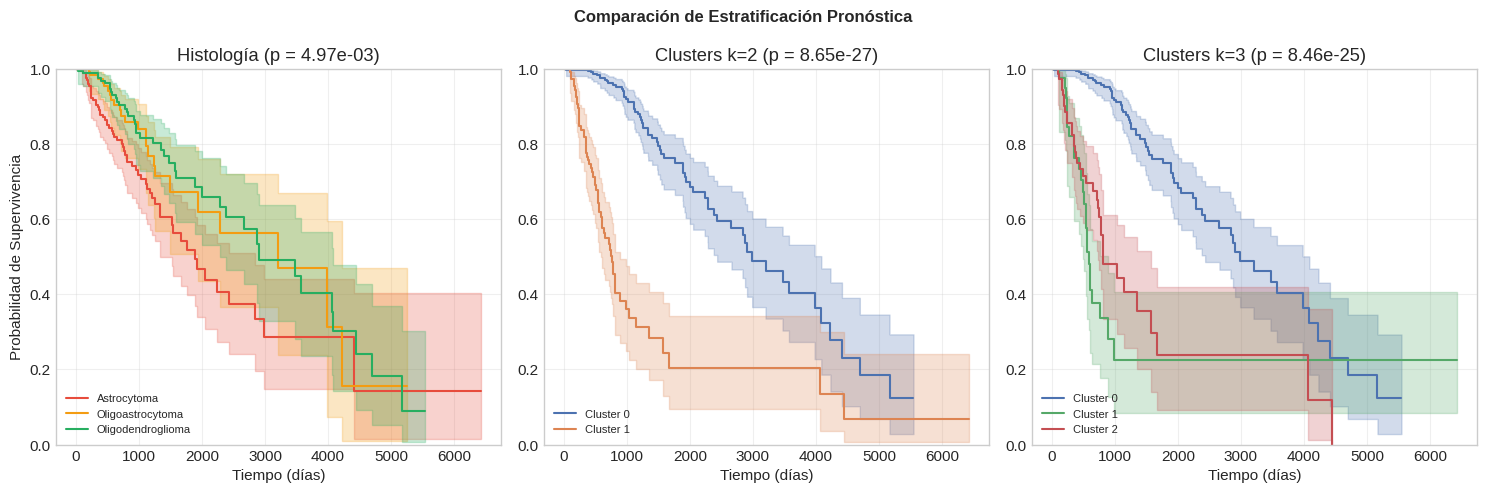

In [32]:
# ==============================================================================
# CURVAS DE KAPLAN-MEIER
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

kmf = KaplanMeierFitter()

colores_hist = {'astrocytoma': '#E74C3C', 'oligoastrocytoma': '#F39C12', 'oligodendroglioma': '#27AE60'}
colores_k2 = {0: '#4C72B0', 1: '#DD8452'}
colores_k3 = {0: '#4C72B0', 1: '#55A868', 2: '#C44E52'}

# --- Panel 1: Histología ---
for tipo in ['astrocytoma', 'oligoastrocytoma', 'oligodendroglioma']:
    mask = histologia_valid == tipo
    kmf.fit(survival_time_valid[mask], event_observed=survival_status_valid[mask], label=tipo.capitalize())
    kmf.plot_survival_function(ax=axes[0], ci_show=True, color=colores_hist[tipo])
axes[0].set_title(f'Histología (p = {p_value_hist:.2e})')
axes[0].set_xlabel('Tiempo (días)')
axes[0].set_ylabel('Probabilidad de Supervivencia')
axes[0].legend(loc='lower left', fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: Clusters k=2 ---
for cluster in [0, 1]:
    mask = labels_k2_valid == cluster
    kmf.fit(survival_time_valid[mask], event_observed=survival_status_valid[mask], label=f'Cluster {cluster}')
    kmf.plot_survival_function(ax=axes[1], ci_show=True, color=colores_k2[cluster])
axes[1].set_title(f'Clusters k=2 (p = {p_value_k2:.2e})')
axes[1].set_xlabel('Tiempo (días)')
axes[1].set_ylabel('')
axes[1].legend(loc='lower left', fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Clusters k=3 ---
for cluster in [0, 1, 2]:
    mask = labels_k3_valid == cluster
    kmf.fit(survival_time_valid[mask], event_observed=survival_status_valid[mask], label=f'Cluster {cluster}')
    kmf.plot_survival_function(ax=axes[2], ci_show=True, color=colores_k3[cluster])
axes[2].set_title(f'Clusters k=3 (p = {p_value_k3:.2e})')
axes[2].set_xlabel('Tiempo (días)')
axes[2].set_ylabel('')
axes[2].legend(loc='lower left', fontsize=8)
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparación de Estratificación Pronóstica', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación del análisis de supervivencia

**Resultados principales:**

| Estratificación | Test log-rank (p-value) | Observación |
|-----------------|-------------------------|-------------|
| Histología (3 grupos) | 4.97×10⁻³ | Separación modesta, curvas solapadas |
| Clusters k=2 | 8.65×10⁻²⁷ | Separación muy marcada |
| Clusters k=3 | 8.46×10⁻²⁵ | Similar a k=2 |

**Observaciones:**

1. **Histología tradicional:** Aunque estadísticamente significativa (p < 0.01), la separación entre curvas es limitada. Los tres tipos histológicos presentan solapamiento considerable en sus trayectorias de supervivencia.

2. **Clusters de metilación (k=2):** Producen una estratificación pronóstica muy superior (p = 8.65×10⁻²⁷), con dos grupos claramente diferenciados: uno de buen pronóstico y otro de mal pronóstico.

3. **Clusters k=3:** Mantienen significación estadística similar, pero la subdivisión adicional no aporta claridad clínica evidente en las curvas.

**Conclusión:** La estratificación basada en metilación supera ampliamente a la histología tradicional para identificar grupos con distinto riesgo vital en esta cohorte.

### 6.5 Selección del Modelo Final

Integrando los resultados de métricas internas (Sección 5) y validación clínica (Sección 6.4), se confirma la selección del modelo.

**Modelo final: K-Means con k=2**

| Criterio | k=2 | k=3 |
|----------|-----|-----|
| Silueta (métrica interna) | 0.314 | 0.270 |
| Log-rank p-value | 8.65×10⁻²⁷ | 8.46×10⁻²⁵ |
| Interpretabilidad | Alta (dos grupos claros) | Media (subdivisión menos clara) |

**Justificación:**

1. **Convergencia de criterios:** Tanto las métricas internas como la validación externa favorecen k=2. La silueta es superior y la estratificación pronóstica es igualmente potente.

2. **Parsimonia:** La solución k=3 no aporta beneficio clínico claro que justifique la complejidad adicional.

3. **Coherencia con la literatura:** La estructura bipartita es compatible con la dicotomía molecular fundamental en gliomas (IDH-mutante vs IDH-wildtype), donde el fenotipo G-CIMP genera el eje principal de variación epigenética [4,8]. Esta interpretación se plantea como hipótesis plausible; no puede confirmarse sin marcadores moleculares (IDH, 1p/19q).

4. **Robustez:** El grupo mayoritario permanece estable entre k=2 y k=3 (394 vs 391 pacientes), sugiriendo que representa una entidad biológica coherente.

### 6.6 Caracterización de los Clusters

Se describen los perfiles clínico-patológicos de los dos clusters identificados.

In [33]:
# ==============================================================================
# 6.6 CARACTERIZACIÓN DE LOS CLUSTERS (k=2)
# ==============================================================================

print("="*70)
print("6.6 CARACTERIZACIÓN DE LOS CLUSTERS")
print("="*70)

df_clusters = pd.DataFrame({
    'cluster_k2': labels_k2_valid,
    'survival_time': survival_time_valid,
    'status': survival_status_valid,
    'histologia': histologia_valid
})

edad_valid_numeric = pd.to_numeric(df_clinical.loc[df_clusters.index, 'years_to_birth'], errors='coerce')
df_clusters['edad'] = np.abs(edad_valid_numeric)

print("\n--- Perfil de cada cluster ---\n")

for cluster in [0, 1]:
    mask = df_clusters['cluster_k2'] == cluster
    n = mask.sum()

    print(f"CLUSTER {cluster} (n = {n}, {n/len(df_clusters)*100:.1f}%)")
    print("-"*50)

    edad_mean = df_clusters.loc[mask, 'edad'].mean()
    edad_std = df_clusters.loc[mask, 'edad'].std()
    print(f"Edad: {edad_mean:.1f} ± {edad_std:.1f} años")

    surv_median = df_clusters.loc[mask, 'survival_time'].median()
    print(f"Supervivencia mediana: {surv_median:.0f} días")

    mort = df_clusters.loc[mask, 'status'].mean() * 100
    print(f"Mortalidad observada: {mort:.1f}%")

    print("Composición histológica:")
    hist_counts = df_clusters.loc[mask, 'histologia'].value_counts()
    for tipo, count in hist_counts.items():
        print(f"  {tipo}: {count} ({count/n*100:.1f}%)")
    print()

6.6 CARACTERIZACIÓN DE LOS CLUSTERS

--- Perfil de cada cluster ---

CLUSTER 0 (n = 371, 77.1%)
--------------------------------------------------
Edad: 41.0 ± 12.1 años
Supervivencia mediana: 854 días
Mortalidad observada: 17.0%
Composición histológica:
  oligodendroglioma: 148 (39.9%)
  astrocytoma: 117 (31.5%)
  oligoastrocytoma: 106 (28.6%)

CLUSTER 1 (n = 110, 22.9%)
--------------------------------------------------
Edad: 50.0 ± 14.5 años
Supervivencia mediana: 542 días
Mortalidad observada: 54.5%
Composición histológica:
  astrocytoma: 63 (57.3%)
  oligodendroglioma: 26 (23.6%)
  oligoastrocytoma: 21 (19.1%)



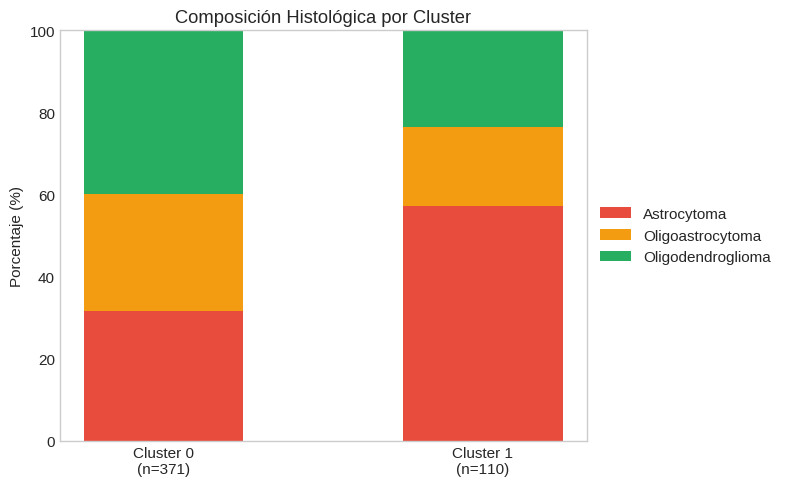

In [34]:
# ==============================================================================
# VISUALIZACIÓN: COMPOSICIÓN HISTOLÓGICA POR CLUSTER
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

clusters = [0, 1]
tipos = ['astrocytoma', 'oligoastrocytoma', 'oligodendroglioma']
colores_hist = {'astrocytoma': '#E74C3C', 'oligoastrocytoma': '#F39C12', 'oligodendroglioma': '#27AE60'}

proporciones = {}
for tipo in tipos:
    proporciones[tipo] = []
    for cluster in clusters:
        mask = df_clusters['cluster_k2'] == cluster
        n_cluster = mask.sum()
        n_tipo = ((df_clusters['cluster_k2'] == cluster) & (df_clusters['histologia'] == tipo)).sum()
        proporciones[tipo].append(n_tipo / n_cluster * 100)

bottom = np.zeros(2)
x_pos = np.array([0, 1])
for tipo in tipos:
    ax.bar(x_pos, proporciones[tipo], bottom=bottom, width=0.5,
           label=tipo.capitalize(), color=colores_hist[tipo])
    bottom += proporciones[tipo]

n_c0 = (df_clusters['cluster_k2'] == 0).sum()
n_c1 = (df_clusters['cluster_k2'] == 1).sum()

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Cluster 0\n(n={n_c0})', f'Cluster 1\n(n={n_c1})'])
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Composición Histológica por Cluster')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

##### Interpretación de los perfiles

Los dos clusters presentan perfiles clínico-patológicos claramente diferenciados:

**Cluster 0 (n=371, 77.1%) - Grupo de mejor pronóstico:**
- Pacientes más jóvenes (41.0 ± 12.1 años)
- Menor mortalidad observada (17.0%)
- Composición histológica mixta, con ligero predominio de oligodendroglioma (39.9%)

**Cluster 1 (n=110, 22.9%) - Grupo de peor pronóstico:**
- Pacientes de mayor edad (50.0 ± 14.5 años)
- Mayor mortalidad observada (54.5%)
- Predominio de astrocitoma (57.3%)

**Observación clave:** Ambos clusters contienen los tres tipos histológicos, confirmando que la clasificación basada en metilación captura información biológica diferente a la morfología tradicional. El Cluster 1 concentra una mayor proporción de astrocitomas, lo cual es coherente con la literatura que asocia este tipo histológico con perfiles moleculares de peor pronóstico cuando carecen de mutación IDH [4,10].

### 6.7 Discusión Final

#### 6.7.1 Validación metodológica

El pipeline implementado se comparó con la metodología reportada en publicaciones de referencia:

| Aspecto | Este trabajo | Literatura (TCGA, Heidelberg) |
|---------|--------------|-------------------------------|
| Preprocesamiento | Imputación (mediana), filtrado por varianza | Normalización/control de calidad específicos de arrays; filtrado por variabilidad (p. ej., MAD/varianza) |
| Escalado | StandardScaler | Centrado + varianza unitaria |
| Reducción dimensional | PCA (94.85% varianza, ≈95%) | PCA (uso variable según objetivo; a menudo para explorar estructura global y/o como paso previo al clustering) |
| Clustering | K-Means, GMM | K-Means, consensus clustering (según estudio) |
| Selección de k | Método del codo + silueta | Estabilidad (resampling/consensus) + validación externa |
| Validación | Kaplan–Meier + log-rank | Kaplan–Meier + log-rank |

El pipeline es metodológicamente coherente con enfoques habituales en cohortes tipo TCGA, donde se combinan selección de características, reducción dimensional (cuando procede) y clustering no supervisado para explorar subgrupos biológicos [4,6]. En este trabajo se emplea PCA como reducción práctica previa a K-Means/GMM (por alcance de este análisis) y se reconoce que alternativas como selección por MAD y/o consensus clustering son frecuentes en trabajos de referencia.

#### 6.7.2 Interpretación molecular de los clusters

Los resultados de supervivencia (p = 8.65×10⁻²⁷ para clusters k=2 vs p = 4.97×10⁻³ para histología) son coherentes con la evidencia de que la estratificación molecular aporta información pronóstica adicional a la histología en gliomas [4,5].

**La estructura bipartita observada (k=2) es compatible con la dicotomía molecular fundamental:**

La mutación *IDH* se asocia a un fenotipo hipermetilador denominado G-CIMP (*Glioma CpG Island Methylator Phenotype*), lo que puede constituir uno de los ejes dominantes de variación en datos de metilación [8,9]. Turcan et al. (2012) demostraron que la mutación *IDH1* es suficiente por sí sola para establecer este fenotipo, afectando miles de sitios CpG [9]. En este trabajo, PC1 captura el 31.2% de la varianza, lo que es compatible con la presencia de un eje epigenético dominante y con la estructura bipartita observada.

**Sobre la solución k=3:**

Aunque la literatura describe tres entidades moleculares en gliomas difusos del adulto (astrocitoma IDH-mutante, oligodendroglioma IDH-mutante con codeleción 1p/19q, glioma IDH-wildtype) [10], en este análisis se seleccionó k=2 como modelo final. Es importante notar que tanto k=2 como k=3 superan ampliamente a la histología en capacidad de estratificación pronóstica (p < 0.001 en ambos casos). Sin embargo, la elección entre ambos se fundamenta en criterios internos: k=2 presenta mejor silueta (0.314 vs 0.270) y la visualización en PCA muestra que k=3 subdivide el cluster minoritario sin generar una separación geométrica adicional clara. Por parsimonia, se prefiere la solución más simple cuando ambas ofrecen validación externa comparable.

La distinción fina dentro de tumores IDH-mutantes (G-CIMP-high vs G-CIMP-low, o según codeleción 1p/19q) es más sutil y puede requerir marcadores moleculares explícitos o selección de características dirigida para emerger con claridad [4].

#### 6.7.3 Limitaciones

1. **Ausencia de variables moleculares:** No se dispone de estado *IDH*, codeleción 1p/19q ni metilación de *MGMT*. La correspondencia entre clusters y subtipos OMS se plantea como hipótesis, no como diagnóstico.

2. **Datos de supervivencia:** Alta censura (74.4%) limita la interpretación en tiempos largos.

3. **Sin ajuste multivariante:** Kaplan-Meier no ajusta por edad, grado o tratamiento.

4. **Validación única:** Resultados de una sola cohorte (TCGA-LGG).

#### 6.7.4 Relevancia clínica

Este hallazgo ejemplifica lo que Ramaswamy y Taylor (2016) denominaron **"la caída del muro óptico"** [2]: la transición del diagnóstico basado en microscopía hacia clasificaciones moleculares integradas, reflejada en las actualizaciones de la clasificación OMS de 2016 y 2021 [5,10].

Desde la perspectiva de Anatomía Patológica, esto es especialmente relevante: la histología sigue siendo esencial, pero por sí sola puede infraestimar tumores biológicamente agresivos o sobredimensionar el riesgo en tumores con perfil molecular favorable. Cuando el tumor "habla" a través de su perfil epigenético, es posible refinar el pronóstico con mayor precisión que con la morfología aislada.

**El hallazgo principal de este trabajo es que, incluso sin marcadores moleculares explícitos, el perfil de metilación permite descubrir grupos con relevancia pronóstica superior a la histología tradicional en esta cohorte.**

## 7. Glosario (términos clave)

- **Astrocitoma / Oligodendroglioma:** tipos histológicos de glioma, definidos tradicionalmente por morfología celular.
- **Censura:** pacientes sin evento observado (p. ej., vivos al final del seguimiento); aportan información hasta su último tiempo registrado.
- **Clasificador de Heidelberg:** herramienta de referencia que clasifica tumores del SNC mediante metilación y Random Forest [6].
- **Clustering no supervisado:** aprendizaje sin etiquetas; busca agrupar pacientes por similitud de perfiles (aquí, metilación).
- **Coeficiente de silueta:** métrica interna de separación/cohesión (−1 a 1); valores más altos indican clusters más coherentes en el espacio usado.
- **CpG:** regiones del ADN donde se mide metilación; el perfil conjunto define firmas epigenéticas útiles para estratificación.
- **Epigenética:** modificaciones del ADN (como metilación) que regulan la expresión génica sin cambiar la secuencia.
- **Fenotipo:** características observables (aquí, patrón de metilación); contrasta con genotipo (secuencia de ADN).
- **G-CIMP:** fenotipo hipermetilador característico en un subgrupo de gliomas (frecuentemente asociado a *IDH* mutado); suele dominar la variación en datos de metilación.
- **Glioma difuso:** tumor infiltrante del SNC; su clasificación moderna depende de diagnóstico integrado (morfología + marcadores moleculares).
- **IDH (Isocitrato Deshidrogenasa):** gen cuya mutación define subtipos de gliomas; es el marcador molecular más importante en la clasificación actual.
- **IDH-mutante:** tumor con mutación en el gen IDH; asociado a mejor pronóstico y fenotipo G-CIMP.
- **IDH-wildtype (tipo salvaje):** tumor sin mutación en IDH; comportamiento más agresivo, similar a glioblastoma.
- **Islas CpG:** regiones del ADN ricas en dinucleótidos CG; su metilación regula la actividad de genes cercanos.
- **k (número de clusters):** hiperparámetro que define cuántos grupos se fuerzan en el clustering; se sugiere con métricas internas (codo/silueta).
- **Kaplan–Meier:** estimación no paramétrica de supervivencia por grupos; permite comparar curvas (test log-rank).
- **LGG (Lower-Grade Glioma):** gliomas difusos de grado II–III (según clasificación tradicional), con alta heterogeneidad molecular.
- **LGm1-LGm6:** seis clusters de metilación identificados por el consorcio TCGA en gliomas difusos [4].
- **Log-rank test:** prueba estadística para comparar curvas de supervivencia entre grupos.
- **MAD (Median Absolute Deviation):** medida de dispersión robusta a valores atípicos; alternativa a la varianza.
- **Metilación del ADN (valores beta):** medida epigenética (0–1) que refleja el estado de metilación en sitios CpG; aquí es la fuente principal de variables.
- **OMS/WHO:** Organización Mundial de la Salud; publica la clasificación oficial de tumores del SNC.
- **PCA:** reducción de dimensionalidad lineal; genera componentes principales que capturan varianza y facilitan clustering/visualización.
- **t-SNE:** proyección no lineal para visualización 2D; útil para "ver estructura", pero no preserva distancias globales.
- **Wildtype:** término genético que significa "sin mutación", es decir, la versión normal del gen.

## 8. Referencias Bibliográficas

[1] Ostrom QT, et al. CBTRUS Statistical Report: Primary Brain and Central Nervous System Tumors Diagnosed in the United States in 2008-2012. Neuro-Oncology. 2015;17(suppl 4):iv1-iv62. DOI: 10.1093/neuonc/nov189

[2] Ramaswamy V, Taylor MD. Fall of the Optical Wall: Freedom from the Tyranny of the Microscope Improves Glioma Risk Stratification. Cancer Cell. 2016;29(2):137-138. DOI: 10.1016/j.ccell.2016.01.007

[3] Cancer Genome Atlas Research Network. Comprehensive, Integrative Genomic Analysis of Diffuse Lower-Grade Gliomas. N Engl J Med. 2015;372(26):2481-2498. DOI: 10.1056/NEJMoa1402121

[4] Ceccarelli M, et al. Molecular Profiling Reveals Biologically Discrete Subsets and Pathways of Progression in Diffuse Glioma. Cell. 2016;164(3):550-563. DOI: 10.1016/j.cell.2015.12.028

[5] Louis DN, et al. The 2016 World Health Organization Classification of Tumors of the Central Nervous System: A Summary. Acta Neuropathol. 2016;131(6):803-820. DOI: 10.1007/s00401-016-1545-1

[6] Capper D, et al. DNA Methylation-Based Classification of Central Nervous System Tumours. Nature. 2018;555(7697):469-474. DOI: 10.1038/nature26000

[7] LinkedOmics Data Portal. TCGA-LGG Datasets. Disponible en: https://www.linkedomics.org/data_download/TCGA-LGG/

[8] Noushmehr H, et al. Identification of a CpG Island Methylator Phenotype that Defines a Distinct Subgroup of Glioma. Cancer Cell. 2010;17(5):510-522. DOI: 10.1016/j.ccr.2010.03.017

[9] Turcan S, et al. IDH1 Mutation is Sufficient to Establish the Glioma Hypermethylator Phenotype. Nature. 2012;483(7390):479-483. DOI: 10.1038/nature10866

[10] Louis DN, et al. The 2021 WHO Classification of Tumors of the Central Nervous System: A Summary. Neuro-Oncology. 2021;23(8):1231-1251. DOI: 10.1093/neuonc/noab106